# Clustering de Prescriptores — `doctors_aggregated_imputed.csv`

Análisis de segmentación de prescriptores usando datos **ya agregados a nivel doctor** (~21k filas).

### Algoritmos aplicados
| Algoritmo | Representante | Formas | Outliers |
|---|---|---|---|
| **K-Means** | Centroide (sintético) | Esféricas | No maneja |
| **K-Medoids (PAM)** | Medoide (punto real) | Esféricas | Robusto |
| **Hierarchical (Ward)** | Dendrograma → corte | Esféricas | No maneja |
| **GMM** | Media de componente | Elipsoidales | Probabilístico |
| **DBSCAN** | Basado en densidad | Arbitrarias | Detecta (label=-1) |

### Diseño experimental
- **Muestra única** compartida por todos los algoritmos → comparación justa
- **`random_state=42`** global para reproducibilidad
- **RobustScaler** (resistente a outliers) + `log1p` en variables sesgadas
- **$k \geq 3$** como restricción de negocio (2 segmentos no es accionable)
- Comparativa **$k_{\text{óptimo}}$ vs $k=3$** con tabla de métricas
- **DBSCAN** no usa $k$ — descubre clusters por densidad; se incluye para comparar

## 1. Imports y configuración global

In [104]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, pairwise_distances)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ── Configuración global ──
SEED = 42
np.random.seed(SEED)

# ── K-Medoids (PAM) — implementación compatible con NumPy 2.x ──
class KMedoids:
    """PAM K-Medoids: los medoides son puntos reales del dataset."""
    def __init__(self, n_clusters=3, random_state=42, max_iter=200):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.max_iter = max_iter

    def fit_predict(self, X):
        rng = np.random.RandomState(self.random_state)
        n = len(X)
        medoid_idx = rng.choice(n, self.n_clusters, replace=False)
        for _ in range(self.max_iter):
            D = pairwise_distances(X, X[medoid_idx], metric='euclidean')
            labels = np.argmin(D, axis=1)
            new_med = []
            for c in range(self.n_clusters):
                pts = np.where(labels == c)[0]
                if len(pts) == 0:
                    new_med.append(medoid_idx[c])
                    continue
                Dsub = pairwise_distances(X[pts], X[pts])
                new_med.append(pts[np.argmin(Dsub.sum(axis=1))])
            new_med = np.array(new_med)
            if np.array_equal(np.sort(new_med), np.sort(medoid_idx)):
                break
            medoid_idx = new_med
        self.medoid_indices_ = medoid_idx
        D = pairwise_distances(X, X[medoid_idx])
        self.labels_ = np.argmin(D, axis=1)
        return self.labels_

# ── Paleta y estilo ──
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
           '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('Librerías cargadas — random_state global:', SEED)

Librerías cargadas — random_state global: 42


## 2. Carga y exploración de datos

In [140]:
df_raw = pd.read_csv('doctors_aggregated_imputed.csv')
# Normalize ATSEG nulls: CSV has '0' (string) instead of NaN
df_raw['ATSEG_first'] = df_raw['ATSEG_first'].replace('0', np.nan)
print(f'Shape: {df_raw.shape}')
print(f'Rows (unique doctors): {len(df_raw):,}')
print(f'Columns: {df_raw.columns.shape[0]}')
print(f'Total null values: {df_raw.isnull().sum().sum():,}')
print()

print('ATSEG distribution (prior segmentation):')
print(df_raw['ATSEG_first'].value_counts(dropna=False))
print()

# Column types
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
non_num  = [c for c in df_raw.columns if c not in num_cols]
print(f'Numeric columns: {len(num_cols)}')
print(f'Non-numeric columns: {non_num}')
df_raw.head(3)

Shape: (20931, 152)
Rows (unique doctors): 20,931
Columns: 152
Total null values: 9,032

ATSEG distribution (prior segmentation):
ATSEG_first
NaN      9032
SEG_A    6406
SEG_B    3349
SEG_C    2144
Name: count, dtype: int64

Numeric columns: 149
Non-numeric columns: ['ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']


,NUEVO_ID,UC_TRX_sum,UC_TRX_mean,UC_TRX_max,ORAL_TRX_sum,ORAL_TRX_mean,ORAL_TRX_max,IL23_TRX_sum,IL23_TRX_mean,IL23_TRX_max,...,STATE_7_first,STATE_8_first,"(1940, 1960]_first","(1960, 1980]_first","(1980, 2000]_first",ATSEG_first,WEEK_ID_first,WEEK_ID_last,WEEK_ID_count,age
0,1.0,3.873379,0.045039,0.677346,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,NaN,2025-08-22,2025-04-25,86.0,74
1,2.0,19.603356,0.227946,2.125095,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,2025-02-28,2024-08-23,86.0,58
2,3.0,63.040427,0.733028,2.520976,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,SEG_A,2025-05-16,2024-12-27,86.0,74


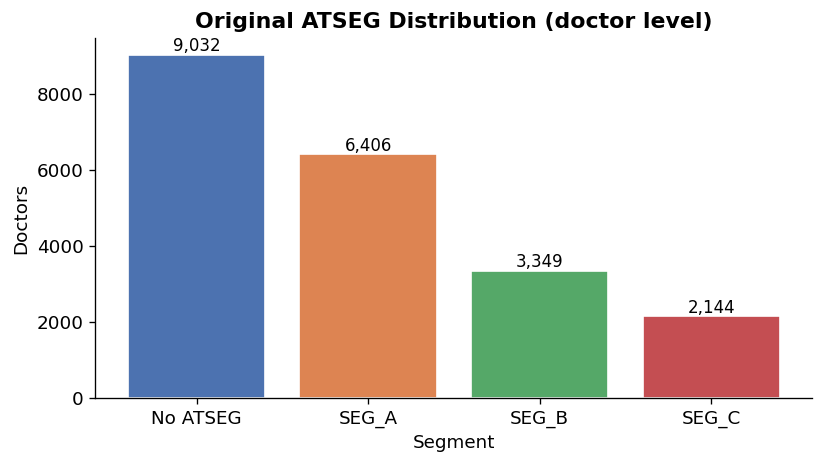

In [141]:
# Visualization: ATSEG distribution

fig, ax = plt.subplots(figsize=(7, 4))

vc = df_raw['ATSEG_first'].fillna('No ATSEG').value_counts().sort_index()

bars = ax.bar(vc.index.astype(str), vc.values, color=PALETTE[:len(vc)], edgecolor='white')

for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}', ha='center', fontsize=10)

ax.set_title('Original ATSEG Distribution (doctor level)', fontweight='bold')
ax.set_ylabel('Doctors')
ax.set_xlabel('Segment')

plt.tight_layout()
plt.show()


## 3. Selección de features y preprocesamiento

**Columnas excluidas del clustering:**
- `NUEVO_ID` — identificador
- `WEEK_ID_first`, `WEEK_ID_last`, `WEEK_ID_count` — temporales
- `ATSEG_first` — etiqueta de referencia (se usa para validación externa, no como feature)
- `SPEC_*`, `STATE_*`, `(1940,1960]_first`, etc. — dummies categóricas (se excluyen del escalado numérico)

**Preprocesamiento:**
1. `log1p` en variables de prescripción muy sesgadas (skewness > 2)
2. `RobustScaler` — usa mediana e IQR, resistente a outliers
3. PCA(2) y t-SNE(2) para visualización

In [142]:
# ── Columns to exclude ──
DROP_COLS = ['NUEVO_ID', 'WEEK_ID_first', 'WEEK_ID_last', 'WEEK_ID_count', 'ATSEG_first', 'age']

# Identify categorical dummies (SPEC_*, STATE_*, STS_*, age brackets)
cat_dummies = [c for c in df_raw.columns
               if c.startswith(('SPEC_', 'STATE_', 'STS_'))
               or c.startswith('(')]

print(f'Categorical dummies ({len(cat_dummies)}): {cat_dummies}')

# Continuous numeric features for clustering
FEATURES = [c for c in df_raw.select_dtypes(include=[np.number]).columns
            if c not in DROP_COLS and c not in cat_dummies]

print(f'\nSelected numeric features: {len(FEATURES)}')

# Save ATSEG for cross-validation later
atseg = df_raw['ATSEG_first'].copy()

# Extract numeric subset
df_feat = df_raw[FEATURES].copy()
print(f'Shape df_feat: {df_feat.shape}')
print(f'Nulls: {df_feat.isnull().sum().sum()}')


Categorical dummies (18): ['SPEC_GE_first', 'SPEC_GPFM_first', 'SPEC_IM_first', 'SPEC_NRP_first', 'SPEC_OTHER_SPEC_first', 'SPEC_PHA_first', 'STATE_1_first', 'STATE_2_first', 'STATE_3_first', 'STATE_4_first', 'STATE_5_first', 'STATE_6_first', 'STS_OTHER_STS_first', 'STATE_7_first', 'STATE_8_first', '(1940, 1960]_first', '(1960, 1980]_first', '(1980, 2000]_first']

Selected numeric features: 128
Shape df_feat: (20931, 128)
Nulls: 0


In [110]:
# ── log1p en columnas con skewness alta ──
skew_vals = df_feat.skew()
high_skew = skew_vals[skew_vals.abs() > 2].index.tolist()
print(f'Columnas con |skewness| > 2: {len(high_skew)}')
for col in high_skew:
    # log1p solo aplica a valores >= 0; para columnas con negativos, desplazar primero
    col_min = df_feat[col].min()
    if col_min < 0:
        df_feat[col] = np.log1p(df_feat[col] - col_min)
    else:
        df_feat[col] = np.log1p(df_feat[col])

print('Skewness después de log1p (top 10):')
print(df_feat[high_skew].skew().sort_values(ascending=False).head(10))

Columnas con |skewness| > 2: 104
Skewness después de log1p (top 10):
NBRx_RATIO_mean                  26.109024
NBRx_RATIO_max                   22.469910
N_CLMBRAND1_NEW_mean             15.461920
N_CLMBRAND1_NEW_sum              14.691741
COPAY_mean                        9.926508
BRAND1_NRX_mean                   9.660846
BRAND1_TRX_mean                   9.091375
N_CLMBRAND4_NEW_TO_BRAND_mean     9.008839
N_CLMBRAND1_mean                  8.939659
SPK_mean                          8.784576
dtype: float64


In [111]:
# ── RobustScaler ──
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_feat)
print(f'X_scaled shape: {X_scaled.shape}')

# ── PCA (2 componentes) para visualización ──
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print(f'Varianza explicada por 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')

# ── Identificar las 2 features más representativas via PCA loadings ──
loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=['PC1', 'PC2'])
loadings['abs_total'] = loadings['PC1'].abs() + loadings['PC2'].abs()
top_features = loadings.nlargest(10, 'abs_total')
print('\nTop 10 features por contribución a PC1+PC2:')
print(top_features[['PC1', 'PC2', 'abs_total']].to_string())

FEAT_X = top_features.index[0]
FEAT_Y = top_features.index[1]
feat_x_idx = list(FEATURES).index(FEAT_X)
feat_y_idx = list(FEATURES).index(FEAT_Y)
print(f'\nFeatures seleccionadas para scatter plots: x={FEAT_X}, y={FEAT_Y}')

# ── t-SNE (2 componentes) — sobre PCA(30) para acelerar ──
pca_30 = PCA(n_components=min(30, X_scaled.shape[1]), random_state=SEED)
X_pca30 = pca_30.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, max_iter=1000, init='pca')
X_tsne = tsne.fit_transform(X_pca30)
print(f't-SNE completado sobre {X_pca30.shape[1]} PCs previos')

X_scaled shape: (20931, 128)
Varianza explicada por 2 PCs: 73.3%
  PC1: 65.8%  PC2: 7.5%

Top 10 features por contribución a PC1+PC2:
                                   PC1       PC2  abs_total
N_CLMBRAND3NEW_TO_BRAND_mean  0.298105 -0.254968   0.553073
N_CLMBRAND3_NEW_mean          0.300127 -0.250659   0.550786
N_CLMOTHERS_NEW_TO_BRAND_max  0.104932  0.416796   0.521728
IL23_NRX_mean                 0.293696 -0.178532   0.472228
IL23_TRX_mean                 0.307227 -0.130245   0.437472
IL23_NBRX_mean                0.256651 -0.145689   0.402340
ORAL_NRX_mean                 0.224912 -0.135040   0.359952
ORAL_NBRX_mean                0.202082 -0.156106   0.358189
N_CLMBRAND3_mean              0.212226 -0.095139   0.307365
N_CLMOTHERS_NEW_max           0.079584  0.223064   0.302647

Features seleccionadas para scatter plots: x=N_CLMBRAND3NEW_TO_BRAND_mean, y=N_CLMBRAND3_NEW_mean
t-SNE completado sobre 30 PCs previos


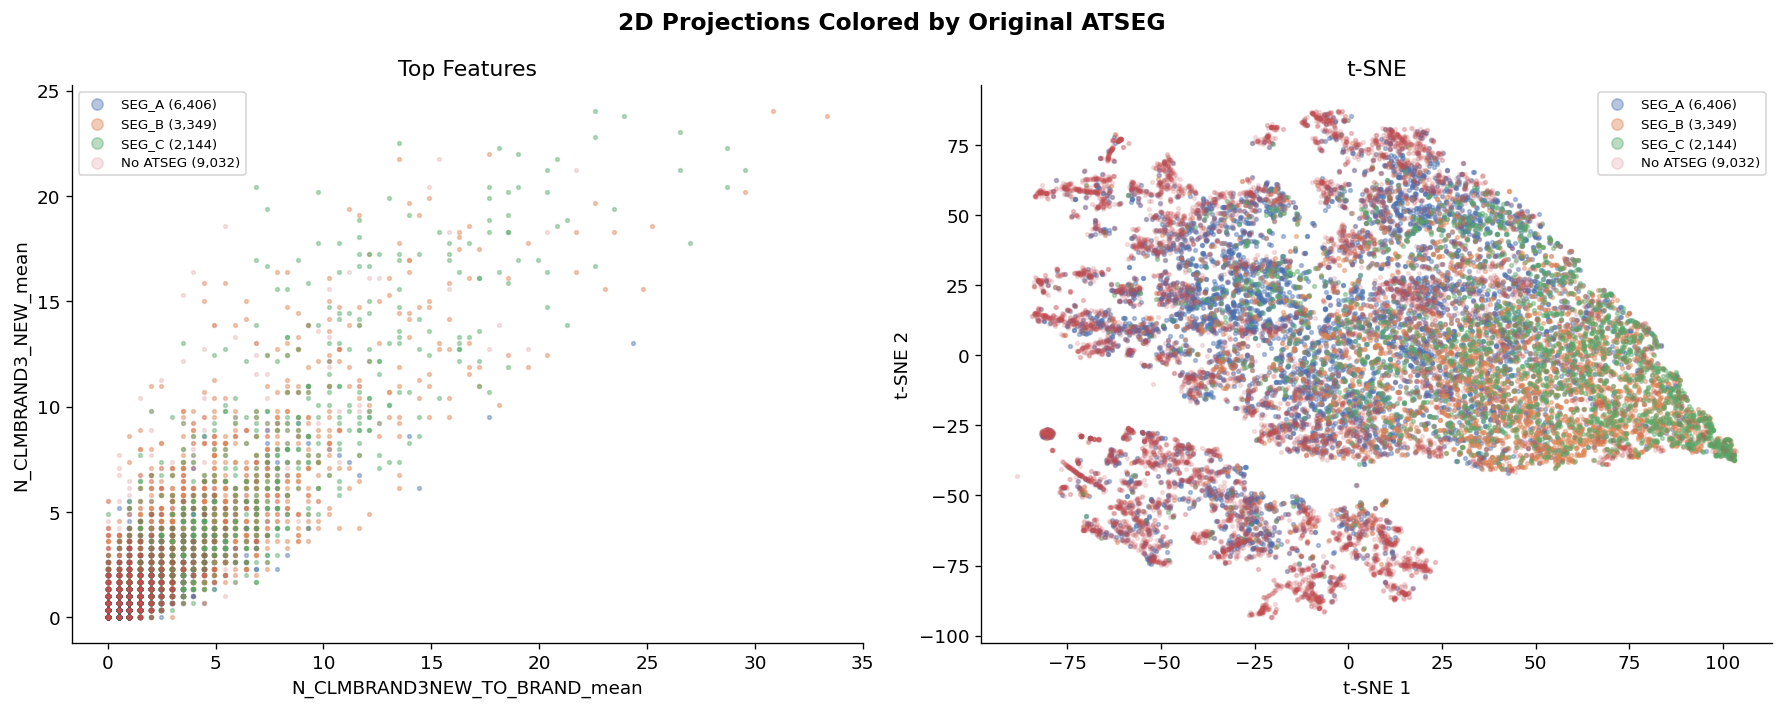

In [143]:
# ── Visualize Top Features and t-SNE colored by ATSEG ──

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('2D Projections Colored by Original ATSEG', fontsize=14, fontweight='bold')

atseg_labels = atseg.fillna('No ATSEG')
atseg_order = ['SEG_A', 'SEG_B', 'SEG_C', 'No ATSEG']
atseg_colors = {s: PALETTE[i] for i, s in enumerate(atseg_order)}

for proj, ax, title, xlabel, ylabel in [
    (X_scaled[:, [feat_x_idx, feat_y_idx]], axes[0], 'Top Features', FEAT_X, FEAT_Y),
    (X_tsne, axes[1], 't-SNE', 't-SNE 1', 't-SNE 2')
]:
    for seg in atseg_order:
        mask = atseg_labels == seg
        alpha = 0.15 if seg == 'No ATSEG' else 0.4
        ax.scatter(proj[mask, 0], proj[mask, 1], s=5, alpha=alpha,
                   color=atseg_colors[seg], label=f'{seg} ({mask.sum():,})')
    ax.set_title(title)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

## 4. Funciones auxiliares

In [144]:
# ── Helper functions ──
K_RANGE = range(3, 9)

def compute_metrics(X, labels):
    """Compute clustering metrics."""
    return {
        'Silhouette': silhouette_score(X, labels, sample_size=5000, random_state=SEED),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
    }

def plot_elbow_silhouette(k_range, silhouettes, algo_name, color,
                          inertias=None, bics=None, aics=None):
    """Plot elbow and/or silhouette for an algorithm."""
    k_opt = list(k_range)[np.argmax(silhouettes)]
    n_plots = 1 + (inertias is not None) + (bics is not None)
    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    idx = 0
    if inertias is not None:
        axes[idx].plot(list(k_range), inertias, 'o-', color=color, lw=2, ms=7)
        axes[idx].axvline(x=k_opt, color='red', ls='--', alpha=0.6, label=f'k_opt={k_opt}')
        axes[idx].set_xlabel('k'); axes[idx].set_ylabel('Inertia (WCSS)')
        axes[idx].set_title(f'Elbow Method — {algo_name}'); axes[idx].set_xticks(list(k_range))
        axes[idx].legend(); axes[idx].grid(True, alpha=0.3)
        idx += 1
    if bics is not None:
        axes[idx].plot(list(k_range), bics, '^-', color=color, lw=2, ms=7, label='BIC')
        axes[idx].plot(list(k_range), aics, 'v-', color='#937860', lw=2, ms=7, label='AIC')
        k_bic = list(k_range)[np.argmin(bics)]
        axes[idx].axvline(x=k_bic, color='red', ls='--', alpha=0.6, label=f'Best BIC k={k_bic}')
        axes[idx].set_xlabel('k'); axes[idx].set_ylabel('Score')
        axes[idx].set_title(f'BIC / AIC — {algo_name}'); axes[idx].set_xticks(list(k_range))
        axes[idx].legend(); axes[idx].grid(True, alpha=0.3)
        idx += 1
    axes[idx].plot(list(k_range), silhouettes, 'o-', color=color, lw=2, ms=7)
    axes[idx].axvline(x=k_opt, color='red', ls='--', alpha=0.6, label=f'k_opt={k_opt}')
    axes[idx].set_xlabel('k'); axes[idx].set_ylabel('Silhouette Score')
    axes[idx].set_title(f'Silhouette — {algo_name}'); axes[idx].set_xticks(list(k_range))
    axes[idx].legend(); axes[idx].grid(True, alpha=0.3)
    fig.suptitle(f'Optimal k Selection — {algo_name} ($k \\geq 3$)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return k_opt

def plot_pca_comparison(labels_opt, labels_3, k_opt, algo_name,
                        centers_opt_pca=None, centers_3_pca=None, center_label='Centroids'):
    """Scatter with Top Features and t-SNE for k_opt and k=3."""
    X_feat = X_scaled[:, [feat_x_idx, feat_y_idx]]

    if k_opt == 3:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'{algo_name} — k=3', fontsize=14, fontweight='bold')
        # Top Features
        ax = axes[0]
        for c in range(3):
            mask = labels_opt == c
            ax.scatter(X_feat[mask, 0], X_feat[mask, 1], s=5, alpha=0.3,
                       color=PALETTE[c % len(PALETTE)], label=f'C{c} ({mask.sum():,})')
        ax.set_title(f'Top Features (k=3)'); ax.set_xlabel(FEAT_X); ax.set_ylabel(FEAT_Y)
        ax.legend(markerscale=2.5, fontsize=8, loc='upper right')
        # t-SNE
        ax = axes[1]
        for c in range(3):
            mask = labels_opt == c
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=5, alpha=0.3,
                       color=PALETTE[c % len(PALETTE)], label=f'C{c} ({mask.sum():,})')
        ax.set_title(f't-SNE (k=3)'); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
        ax.legend(markerscale=2.5, fontsize=8, loc='upper right')
        plt.tight_layout()
        plt.show()
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{algo_name} — k_opt={k_opt} vs k=3', fontsize=14, fontweight='bold')

    for row, (labels, k_val) in enumerate([(labels_opt, k_opt), (labels_3, 3)]):
        # Top Features
        ax = axes[row, 0]
        for c in range(k_val):
            mask = labels == c
            ax.scatter(X_feat[mask, 0], X_feat[mask, 1], s=5, alpha=0.3,
                       color=PALETTE[c % len(PALETTE)], label=f'C{c} ({mask.sum():,})')
        ax.set_title(f'Top Features (k={k_val})'); ax.set_xlabel(FEAT_X); ax.set_ylabel(FEAT_Y)
        ax.legend(markerscale=2.5, fontsize=8, loc='upper right')
        # t-SNE
        ax = axes[row, 1]
        for c in range(k_val):
            mask = labels == c
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=5, alpha=0.3,
                       color=PALETTE[c % len(PALETTE)], label=f'C{c} ({mask.sum():,})')
        ax.set_title(f't-SNE (k={k_val})'); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
        ax.legend(markerscale=2.5, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

def compare_table(algo_name, k_opt, m_opt, m_3):
    """Metrics table k_opt vs k=3 (or single if k_opt == 3)."""
    if k_opt == 3:
        rows = [
            {'Algorithm': algo_name, 'k': k_opt, 'Type': 'optimal', **m_opt}
        ]
        df = pd.DataFrame(rows).round(4)
        print(f'\n{algo_name} — k_optimal=3:')
        print(df.to_string(index=False))
        return df

    rows = [
        {'Algorithm': algo_name, 'k': k_opt, 'Type': 'optimal', **m_opt},
        {'Algorithm': algo_name, 'k': 3,     'Type': 'business', **m_3},
    ]
    df = pd.DataFrame(rows).round(4)
    print(f'\n{algo_name} — k_optimal={k_opt} vs k=3:')
    print(df.to_string(index=False))
    return df

TOP_FEAT = ['UC_TRX_sum', 'ORAL_TRX_sum', 'IL23_TRX_sum',
            'BRAND1_TRX_sum', 'BRAND2_TRX_sum',
            'RTE_sum', 'SAMPLES_sum', 'DETAILS_sum',
            'ENGAGEMENT_SCORE_sum', 'TOTAL_TRX_sum']
try:
    TOP_FEAT = [f for f in TOP_FEAT if f in FEATURES]
except NameError:
    pass

all_comparison_rows = []
all_labels = {}

print('Helper functions loaded')


Helper functions loaded


## 5. K-Means

### 5.1 Búsqueda de k óptimo

  K-Means k=3  inertia=     649,490  silhouette=0.3868
  K-Means k=4  inertia=     554,886  silhouette=0.2892
  K-Means k=5  inertia=     504,549  silhouette=0.2177
  K-Means k=6  inertia=     465,889  silhouette=0.2049
  K-Means k=7  inertia=     435,553  silhouette=0.2077
  K-Means k=8  inertia=     413,363  silhouette=0.1969


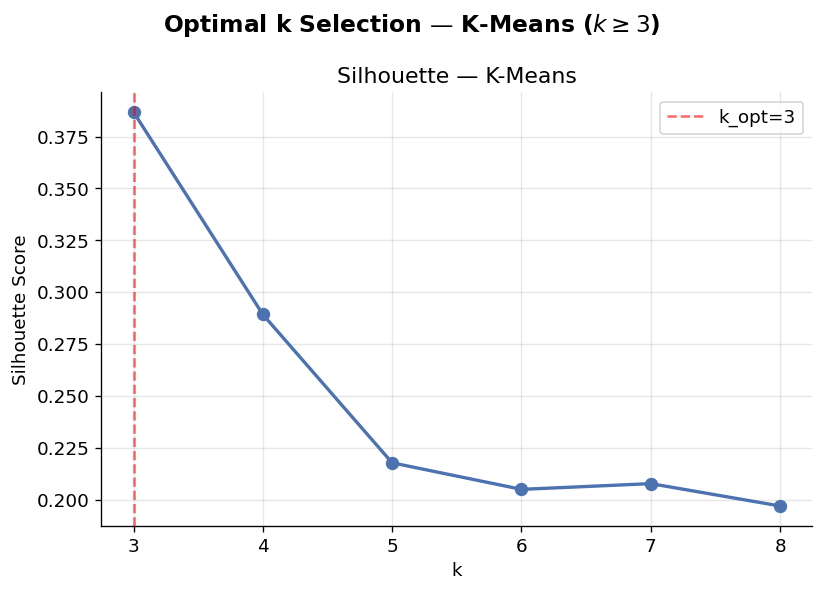


→ Optimal k K-Means: 3


In [145]:
# ── K-Means: Elbow + Silhouette ──
km_inertias, km_silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labs = km.fit_predict(X_scaled)
    km_inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labs, sample_size=5000, random_state=SEED)
    km_silhouettes.append(sil)
    print(f'  K-Means k={k}  inertia={km.inertia_:>12,.0f}  silhouette={sil:.4f}')

K_OPT_KM = plot_elbow_silhouette(K_RANGE, km_silhouettes, 'K-Means', '#4C72B0')
print(f'\n→ Optimal k K-Means: {K_OPT_KM}')

### 5.2 Ejecución: k_óptimo vs k=3

In [115]:
# ── K-Means: ejecutar con k_opt y k=3 ──
kmeans_opt = KMeans(n_clusters=K_OPT_KM, random_state=SEED, n_init=20)
labels_km_opt = kmeans_opt.fit_predict(X_scaled)
m_km_opt = compute_metrics(X_scaled, labels_km_opt)
centroids_km_opt_pca = pca.transform(kmeans_opt.cluster_centers_)

kmeans_3 = KMeans(n_clusters=3, random_state=SEED, n_init=20)
labels_km_3 = kmeans_3.fit_predict(X_scaled)
m_km_3 = compute_metrics(X_scaled, labels_km_3)
centroids_km_3_pca = pca.transform(kmeans_3.cluster_centers_)

all_labels[('K-Means', K_OPT_KM)] = labels_km_opt
all_labels[('K-Means', 3)] = labels_km_3

print(f'K-Means k={K_OPT_KM} (óptimo): {dict(zip(*np.unique(labels_km_opt, return_counts=True)))}')
print(f'K-Means k=3:             {dict(zip(*np.unique(labels_km_3, return_counts=True)))}')

K-Means k=3 (óptimo): {np.int32(0): np.int64(5506), np.int32(1): np.int64(14697), np.int32(2): np.int64(728)}
K-Means k=3:             {np.int32(0): np.int64(5506), np.int32(1): np.int64(14697), np.int32(2): np.int64(728)}


### 5.3 Visualización y comparación

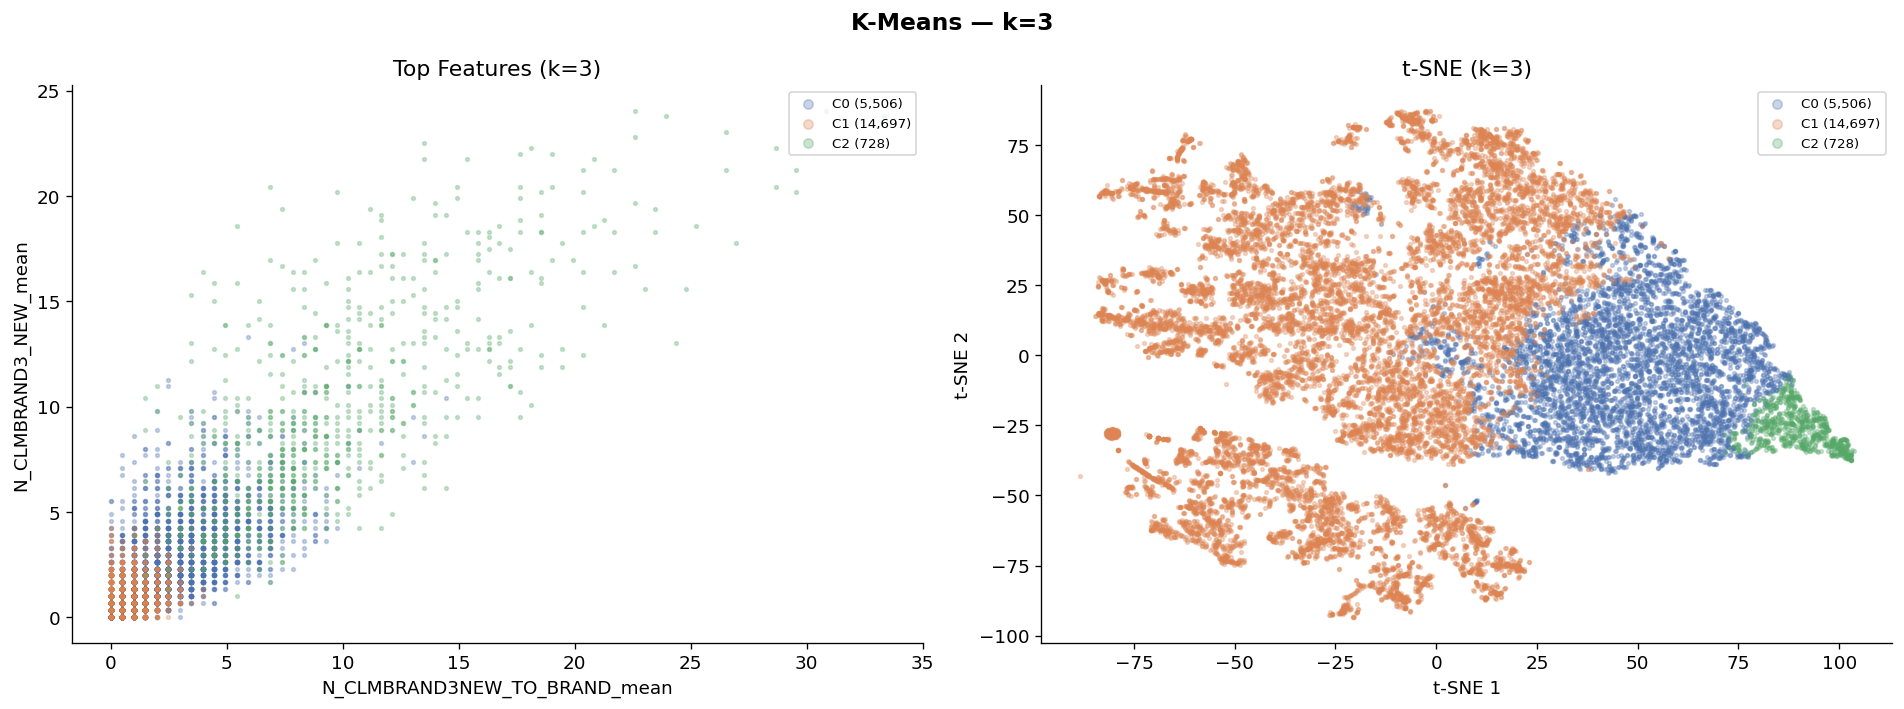


K-Means — k_optimal=3:
Algorithm  k    Type  Silhouette  Davies-Bouldin  Calinski-Harabasz
  K-Means  3 optimal      0.3868          1.0768         13673.9428


In [146]:
# ── K-Means: PCA k_opt vs k=3 ──
plot_pca_comparison(labels_km_opt, labels_km_3, K_OPT_KM, 'K-Means',
              centers_opt_pca=centroids_km_opt_pca, centers_3_pca=centroids_km_3_pca,
              center_label='Centroides')

df_km = compare_table('K-Means', K_OPT_KM, m_km_opt, m_km_3)
all_comparison_rows.extend(df_km.to_dict('records'))

## 6. K-Medoids (PAM)

### 6.1 Búsqueda de k óptimo

  K-Medoids k=3  silhouette=0.1958
  K-Medoids k=4  silhouette=0.1159
  K-Medoids k=5  silhouette=0.1657
  K-Medoids k=6  silhouette=0.1392
  K-Medoids k=7  silhouette=0.1463
  K-Medoids k=8  silhouette=0.1440


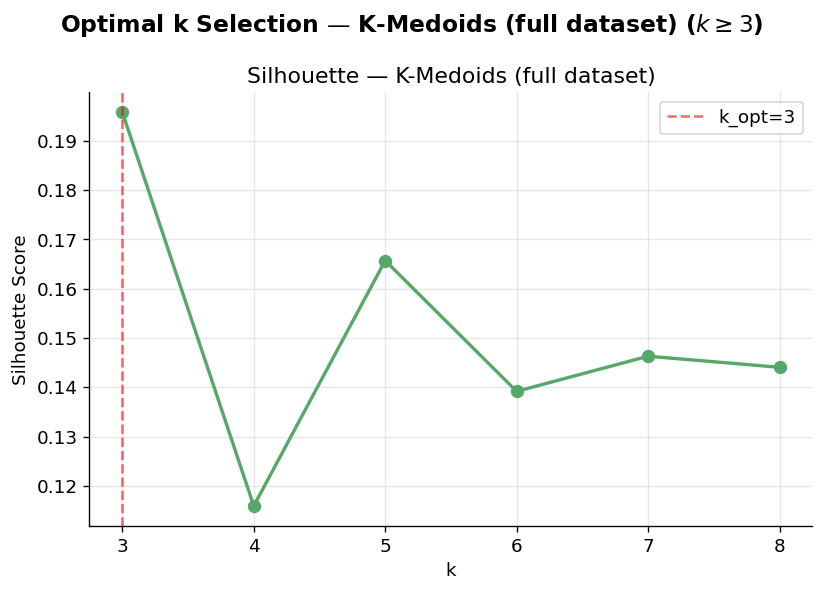


→ Optimal k K-Medoids: 3


In [147]:
# ── K-Medoids: Silhouette by k (full dataset ~21k) ──
kmed_silhouettes = []
for k in K_RANGE:
    kmed = KMedoids(n_clusters=k, random_state=SEED, max_iter=150)
    labs = kmed.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labs, sample_size=5000, random_state=SEED)
    kmed_silhouettes.append(sil)
    print(f'  K-Medoids k={k}  silhouette={sil:.4f}')

K_OPT_KMED = plot_elbow_silhouette(K_RANGE, kmed_silhouettes, 'K-Medoids (full dataset)', '#55A868')
print(f'\n→ Optimal k K-Medoids: {K_OPT_KMED}')

### 6.2 Ejecución: k_óptimo vs k=3

In [118]:
# ── K-Medoids: ejecutar con k_opt y k=3 sobre dataset completo ──
kmedoids_opt = KMedoids(n_clusters=K_OPT_KMED, random_state=SEED, max_iter=200)
labels_kmed_opt = kmedoids_opt.fit_predict(X_scaled)
m_kmed_opt = compute_metrics(X_scaled, labels_kmed_opt)
medoids_opt_pca = X_pca[kmedoids_opt.medoid_indices_]

kmedoids_3 = KMedoids(n_clusters=3, random_state=SEED, max_iter=200)
labels_kmed_3 = kmedoids_3.fit_predict(X_scaled)
m_kmed_3 = compute_metrics(X_scaled, labels_kmed_3)
medoids_3_pca = X_pca[kmedoids_3.medoid_indices_]

all_labels[('K-Medoids', K_OPT_KMED)] = labels_kmed_opt
all_labels[('K-Medoids', 3)] = labels_kmed_3

print(f'K-Medoids k={K_OPT_KMED} (óptimo): {dict(zip(*np.unique(labels_kmed_opt, return_counts=True)))}')
print(f'K-Medoids k=3:             {dict(zip(*np.unique(labels_kmed_3, return_counts=True)))}')

K-Medoids k=3 (óptimo): {np.int64(0): np.int64(4453), np.int64(1): np.int64(9136), np.int64(2): np.int64(7342)}
K-Medoids k=3:             {np.int64(0): np.int64(4453), np.int64(1): np.int64(9136), np.int64(2): np.int64(7342)}


### 6.3 Visualización y comparación

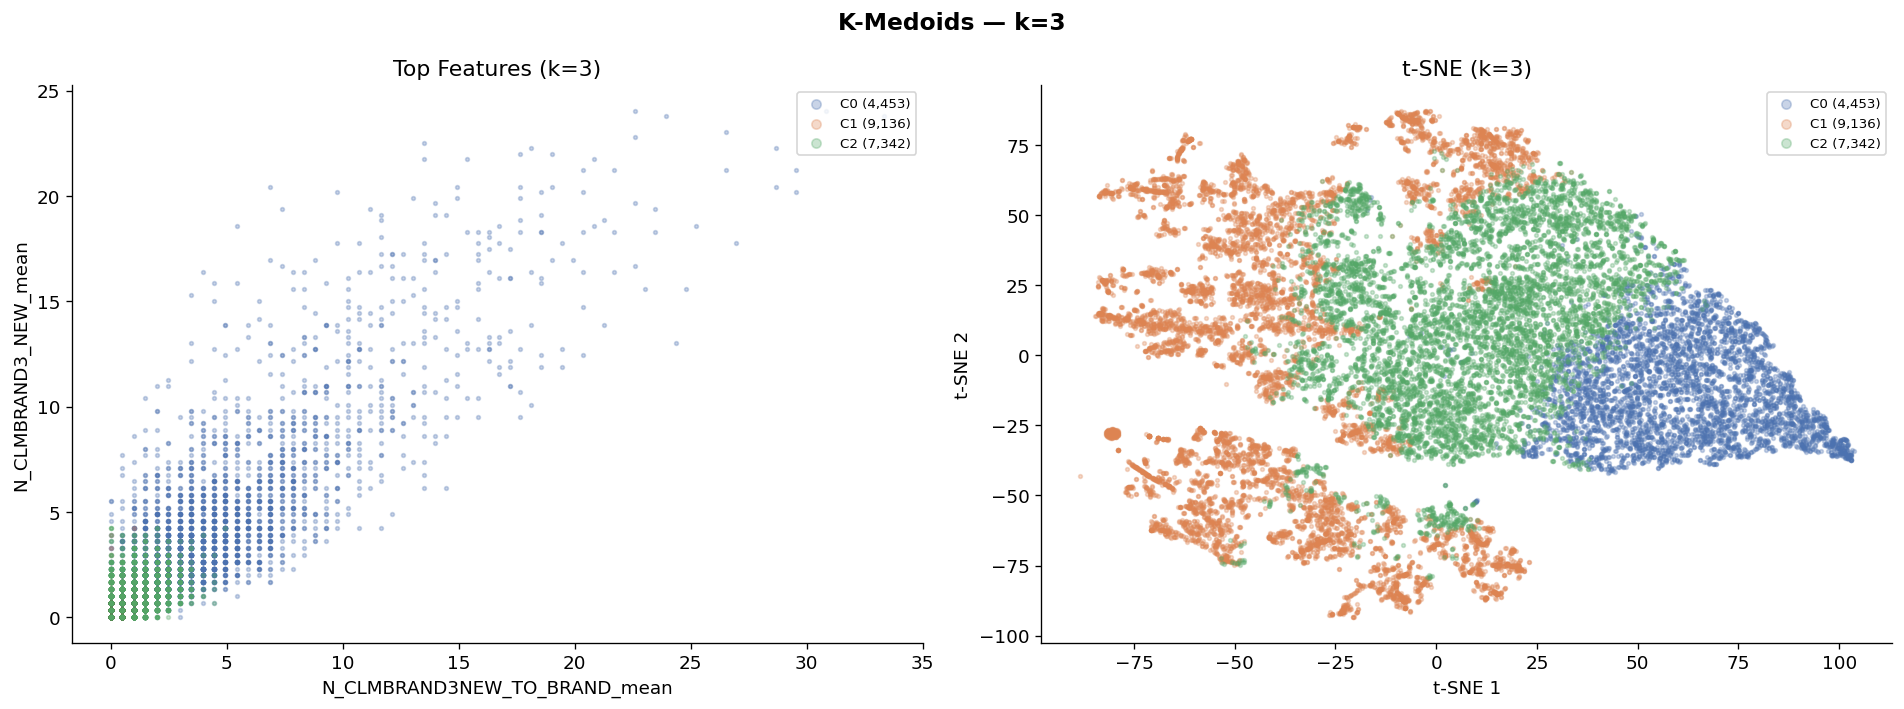


K-Medoids — k_optimal=3:
Algorithm  k    Type  Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Medoids  3 optimal      0.1958           1.515          8418.2414


In [148]:
plot_pca_comparison(labels_kmed_opt, labels_kmed_3, K_OPT_KMED, 'K-Medoids',
              centers_opt_pca=medoids_opt_pca, centers_3_pca=medoids_3_pca,
              center_label='Medoides')

df_kmed = compare_table('K-Medoids', K_OPT_KMED, m_kmed_opt, m_kmed_3)
all_comparison_rows.extend(df_kmed.to_dict('records'))

## 7. Hierarchical Clustering (Ward)

### 7.1 Búsqueda de k óptimo

  Hierarchical k=3  silhouette=0.4210
  Hierarchical k=4  silhouette=0.2191
  Hierarchical k=5  silhouette=0.2168
  Hierarchical k=6  silhouette=0.1698
  Hierarchical k=7  silhouette=0.1709
  Hierarchical k=8  silhouette=0.1751


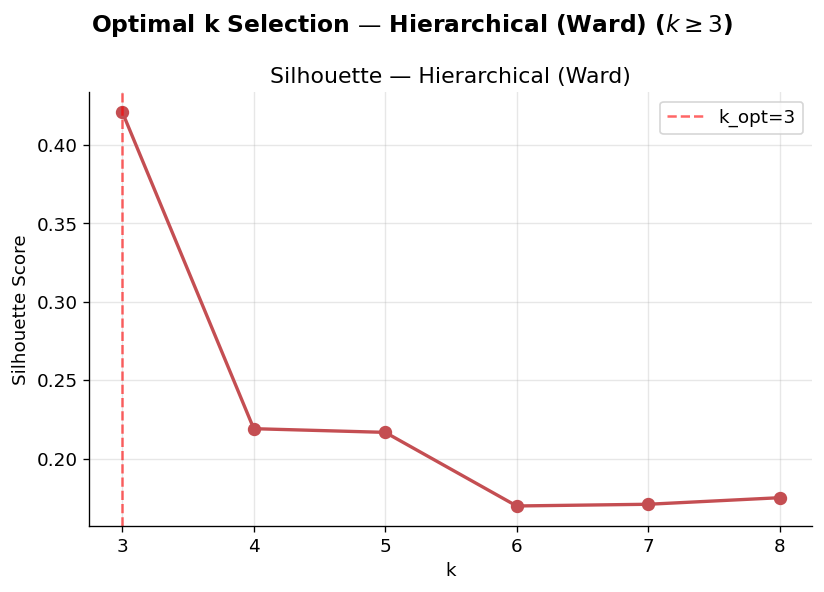


→ Optimal k Hierarchical: 3


In [149]:
# ── Hierarchical (Ward): Silhouette by k ──
Z = linkage(X_pca30, method='ward', metric='euclidean')

hier_silhouettes = []
for k in K_RANGE:
    labs = fcluster(Z, t=k, criterion='maxclust') - 1
    sil = silhouette_score(X_scaled, labs, sample_size=5000, random_state=SEED)
    hier_silhouettes.append(sil)
    print(f'  Hierarchical k={k}  silhouette={sil:.4f}')

K_OPT_HIER = plot_elbow_silhouette(K_RANGE, hier_silhouettes, 'Hierarchical (Ward)', '#C44E52')
print(f'\n→ Optimal k Hierarchical: {K_OPT_HIER}')

### 7.2 Ejecución: k_óptimo vs k=3

Hierarchical k=3 (optimal): {np.int32(0): np.int64(16591), np.int32(1): np.int64(530), np.int32(2): np.int64(3810)}
Hierarchical k=3:             {np.int32(0): np.int64(16591), np.int32(1): np.int64(530), np.int32(2): np.int64(3810)}


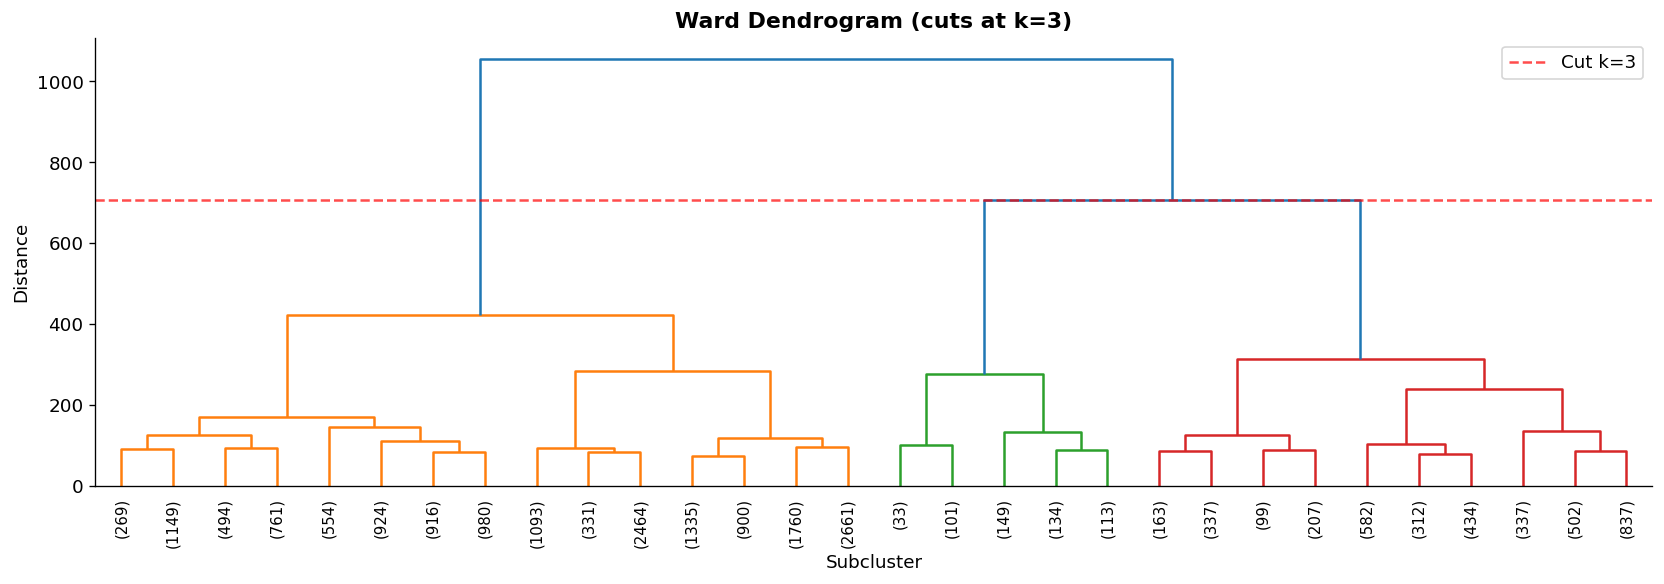

In [150]:
# ── Hierarchical: k_opt and k=3 ──
labels_hier_opt = fcluster(Z, t=K_OPT_HIER, criterion='maxclust') - 1
m_hier_opt = compute_metrics(X_scaled, labels_hier_opt)

labels_hier_3 = fcluster(Z, t=3, criterion='maxclust') - 1
m_hier_3 = compute_metrics(X_scaled, labels_hier_3)

all_labels[('Hierarchical', K_OPT_HIER)] = labels_hier_opt
all_labels[('Hierarchical', 3)] = labels_hier_3

print(f'Hierarchical k={K_OPT_HIER} (optimal): {dict(zip(*np.unique(labels_hier_opt, return_counts=True)))}')
print(f'Hierarchical k=3:             {dict(zip(*np.unique(labels_hier_3, return_counts=True)))}')

# Dendrogram with cut lines
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, color_threshold=Z[-(3-1), 2], ax=ax)
ax.axhline(y=Z[-(3-1), 2], color='red', ls='--', alpha=0.7, label=f'Cut k=3')
if K_OPT_HIER != 3:
    ax.axhline(y=Z[-(K_OPT_HIER-1), 2], color='blue', ls='--', alpha=0.7, label=f'Cut k={K_OPT_HIER}')
ax.set_title(f'Ward Dendrogram (cuts at k=3)', fontweight='bold')
ax.set_xlabel('Subcluster'); ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Visualización y comparación

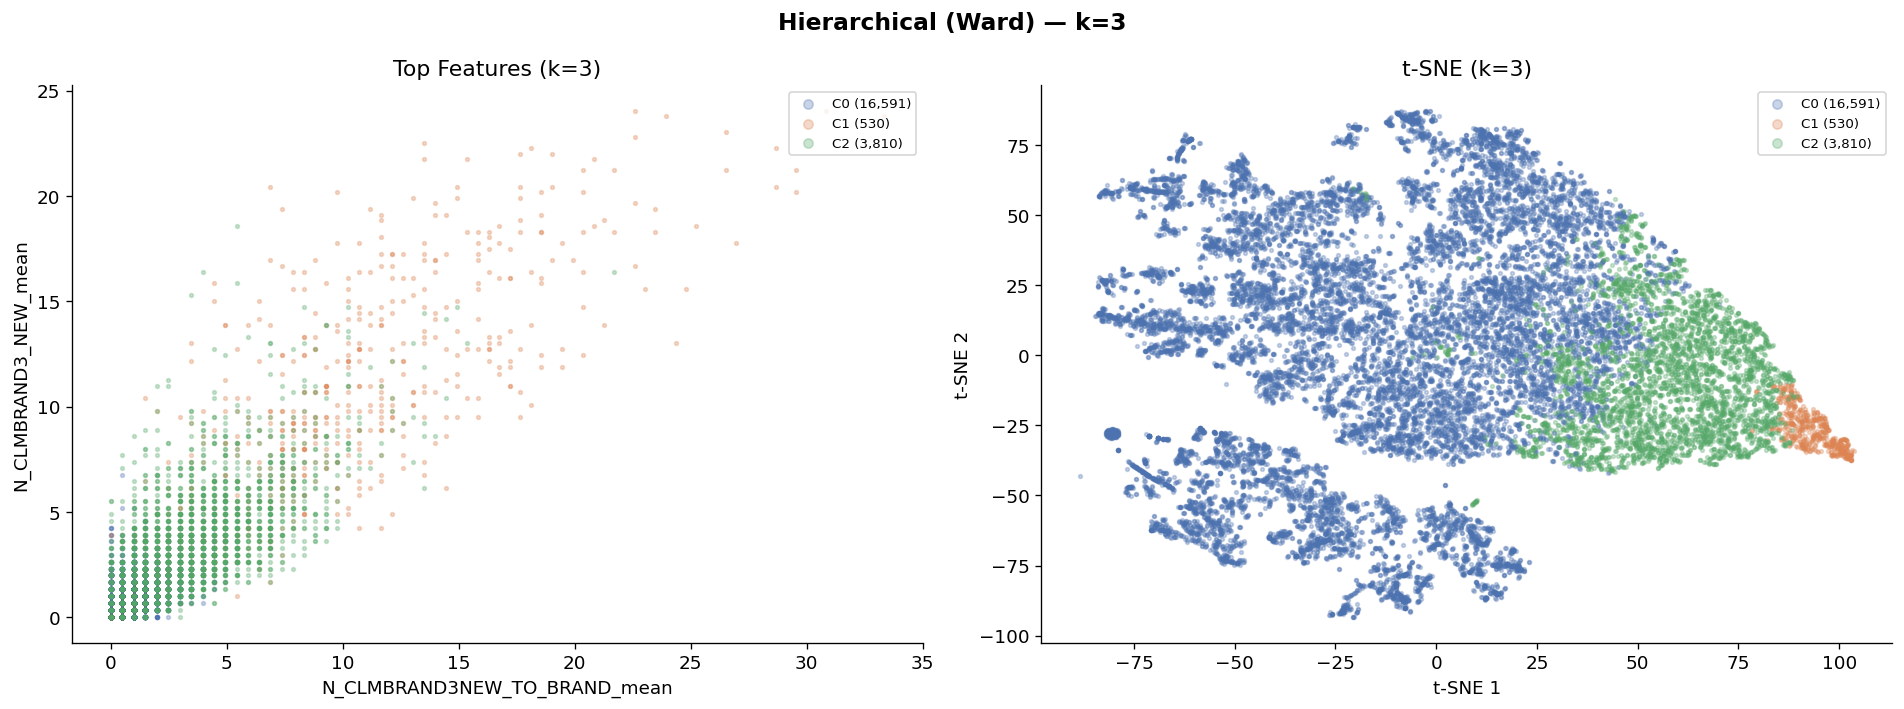


Hierarchical — k_optimal=3:
   Algorithm  k    Type  Silhouette  Davies-Bouldin  Calinski-Harabasz
Hierarchical  3 optimal       0.421          1.0486         12177.1161


In [151]:
plot_pca_comparison(labels_hier_opt, labels_hier_3, K_OPT_HIER, 'Hierarchical (Ward)')

df_hier = compare_table('Hierarchical', K_OPT_HIER, m_hier_opt, m_hier_3)
all_comparison_rows.extend(df_hier.to_dict('records'))

## 8. Gaussian Mixture Models (GMM)

### 8.1 Búsqueda de k óptimo

  GMM k=3  BIC=  -13,913,815.5  silhouette=0.2283
  GMM k=4  BIC=  -14,114,407.0  silhouette=0.2463
  GMM k=5  BIC=  -15,396,279.1  silhouette=0.1327
  GMM k=6  BIC=  -15,235,017.1  silhouette=0.1153
  GMM k=7  BIC=  -15,133,830.8  silhouette=0.1087
  GMM k=8  BIC=  -15,513,944.3  silhouette=0.0956


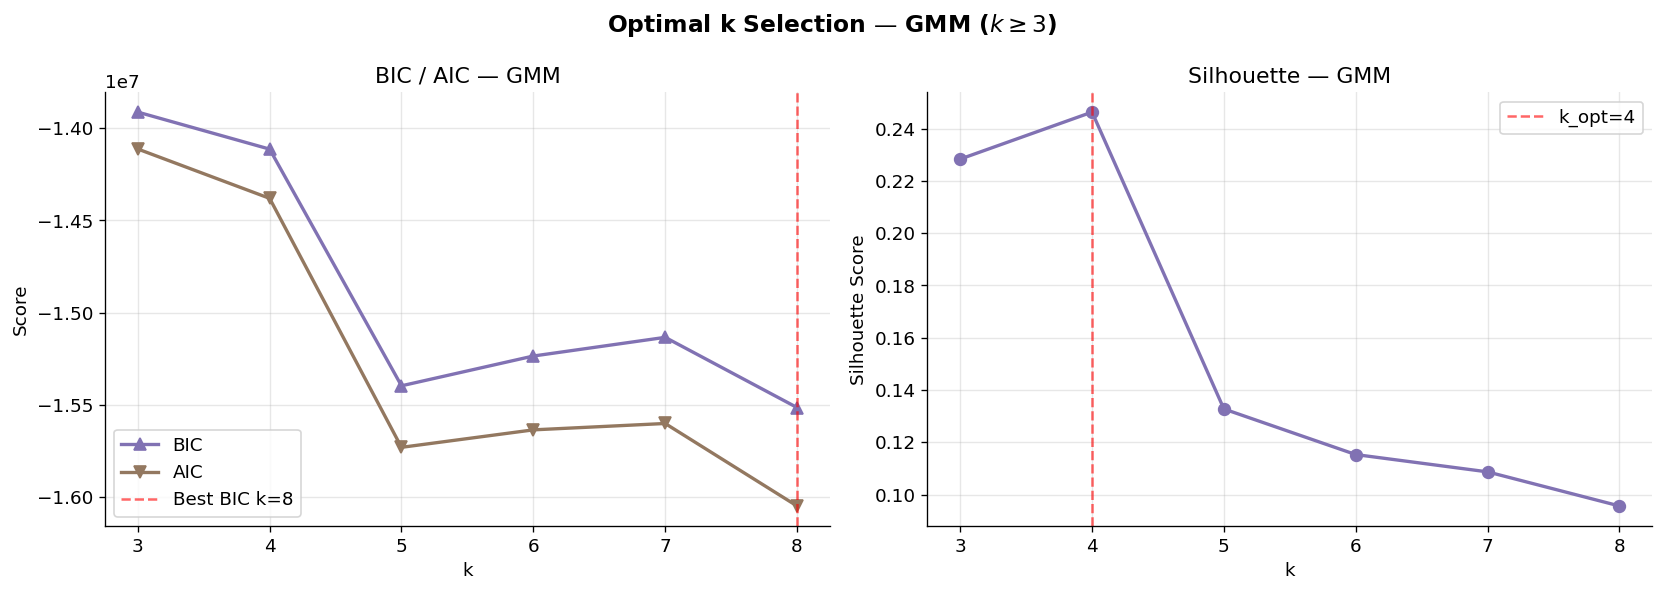


→ Optimal k GMM: 4


In [152]:
# ── GMM: BIC + Silhouette by k ──
gmm_bics, gmm_aics, gmm_silhouettes = [], [], []
for k in K_RANGE:
    g = GaussianMixture(n_components=k, random_state=SEED, covariance_type='full', n_init=5)
    labs = g.fit_predict(X_scaled)
    bic = g.bic(X_scaled)
    aic = g.aic(X_scaled)
    sil = silhouette_score(X_scaled, labs, sample_size=5000, random_state=SEED)
    gmm_bics.append(bic)
    gmm_aics.append(aic)
    gmm_silhouettes.append(sil)
    print(f'  GMM k={k}  BIC={bic:>15,.1f}  silhouette={sil:.4f}')

K_OPT_GMM = plot_elbow_silhouette(K_RANGE, gmm_silhouettes, 'GMM', '#8172B3',
                                  bics=gmm_bics, aics=gmm_aics)
print(f'\n→ Optimal k GMM: {K_OPT_GMM}')

### 8.2 Ejecución: k_óptimo vs k=3

In [124]:
# ── GMM: k_opt y k=3 ──
gmm_opt = GaussianMixture(n_components=K_OPT_GMM, random_state=SEED, covariance_type='full', n_init=5)
labels_gmm_opt = gmm_opt.fit_predict(X_scaled)
m_gmm_opt = compute_metrics(X_scaled, labels_gmm_opt)
gmm_opt_means_pca = pca.transform(gmm_opt.means_)

gmm_3 = GaussianMixture(n_components=3, random_state=SEED, covariance_type='full', n_init=5)
labels_gmm_3 = gmm_3.fit_predict(X_scaled)
m_gmm_3 = compute_metrics(X_scaled, labels_gmm_3)
gmm_3_means_pca = pca.transform(gmm_3.means_)

all_labels[('GMM', K_OPT_GMM)] = labels_gmm_opt
all_labels[('GMM', 3)] = labels_gmm_3

print(f'GMM k={K_OPT_GMM} (óptimo): {dict(zip(*np.unique(labels_gmm_opt, return_counts=True)))}')
print(f'GMM k=3:         {dict(zip(*np.unique(labels_gmm_3, return_counts=True)))}')
print(f'\nBIC k={K_OPT_GMM}: {gmm_opt.bic(X_scaled):,.1f}  |  BIC k=3: {gmm_3.bic(X_scaled):,.1f}')

GMM k=4 (óptimo): {np.int64(0): np.int64(5891), np.int64(1): np.int64(1819), np.int64(2): np.int64(12354), np.int64(3): np.int64(867)}
GMM k=3:         {np.int64(0): np.int64(3691), np.int64(1): np.int64(2660), np.int64(2): np.int64(14580)}

BIC k=4: -14,114,407.0  |  BIC k=3: -13,913,815.5


### 8.3 Visualización y comparación

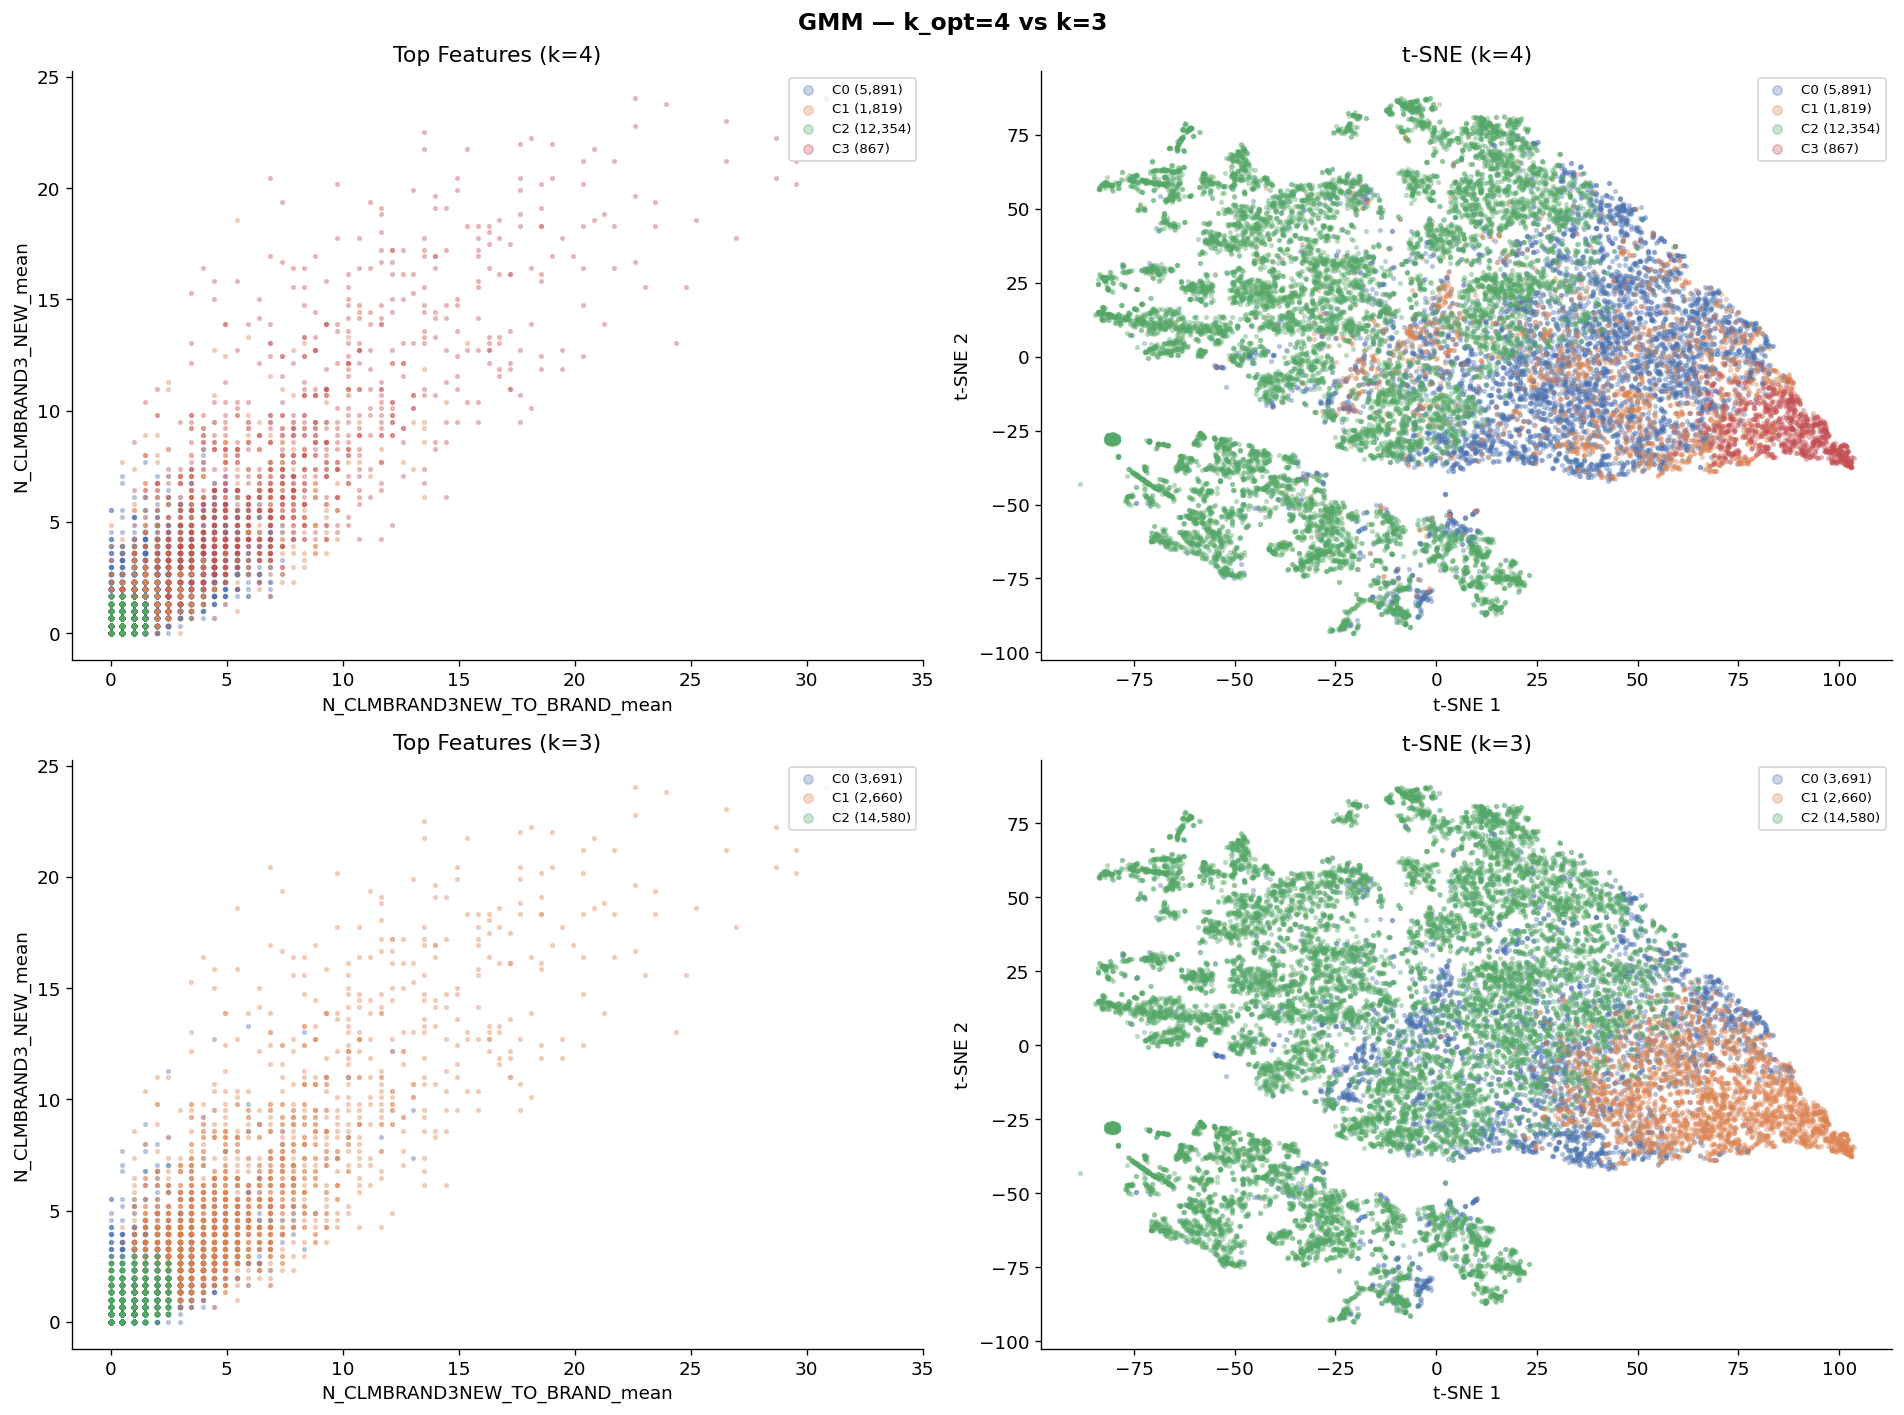


GMM — k_óptimo=4 vs k=3:
Algoritmo  k    Tipo  Silhouette  Davies-Bouldin  Calinski-Harabasz
      GMM  4  óptimo      0.2463          3.0275          7356.6468
      GMM  3 negocio      0.2283          1.8660          7257.8471


In [125]:
plot_pca_comparison(labels_gmm_opt, labels_gmm_3, K_OPT_GMM, 'GMM',
              centers_opt_pca=gmm_opt_means_pca, centers_3_pca=gmm_3_means_pca,
              center_label='Medias GMM')

df_gmm = compare_table('GMM', K_OPT_GMM, m_gmm_opt, m_gmm_3)
all_comparison_rows.extend(df_gmm.to_dict('records'))

## 9. DBSCAN

DBSCAN no requiere especificar $k$ — descubre clusters por densidad usando dos parámetros:
- **`eps`**: radio máximo de vecindad
- **`min_samples`**: puntos mínimos para formar un cluster denso

Los puntos que no pertenecen a ningún cluster se etiquetan como **ruido (label=-1)**.

### 9.1 Selección de eps (k-distance plot)

min_samples = 50 (heuristic: min(2*n_features, 50))


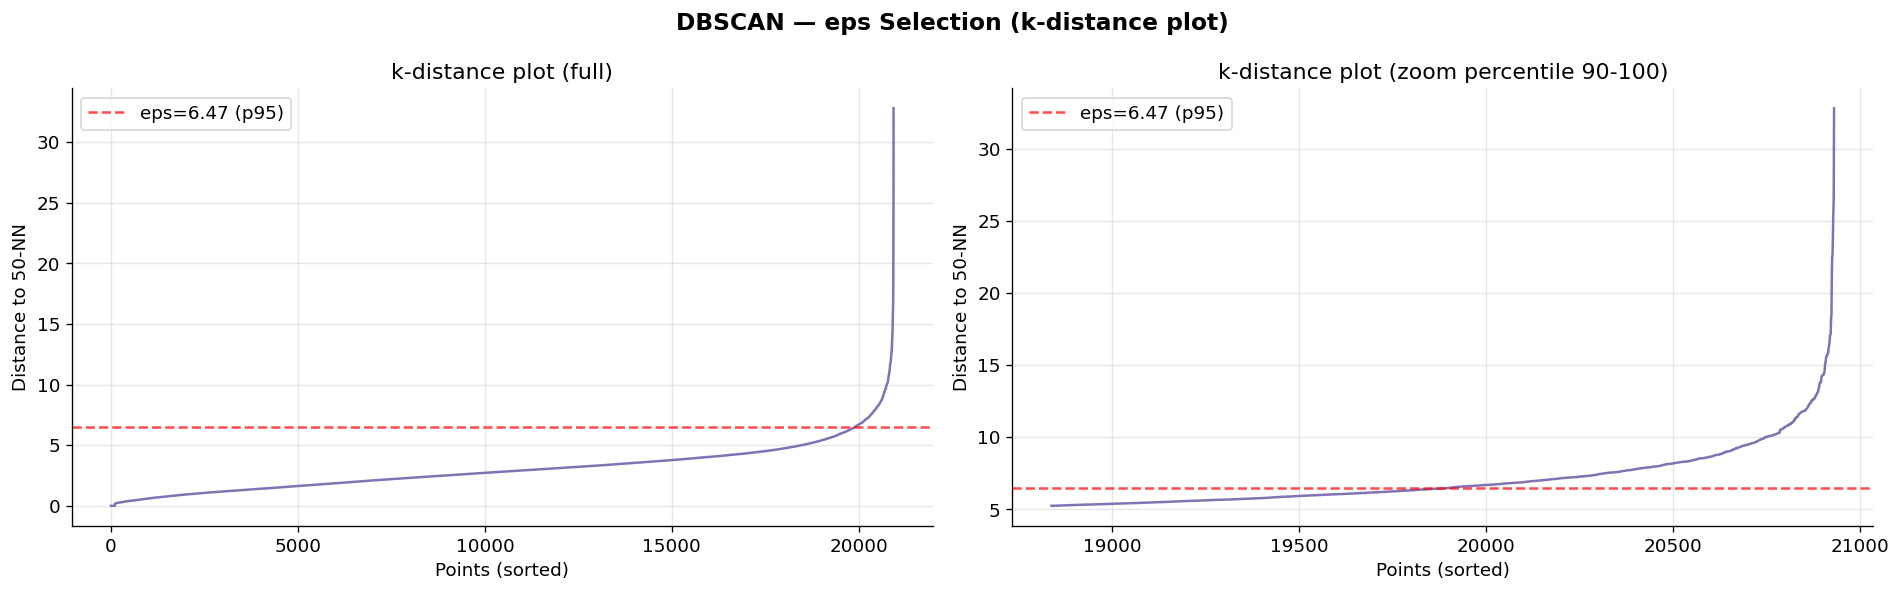


→ Selected eps (95th percentile): 6.4654
→ min_samples: 50


In [153]:
# ── DBSCAN: k-distance plot to select eps ──
# Compute distance to k-th nearest neighbor (k=min_samples)
MIN_SAMPLES = 2 * X_scaled.shape[1]  # heuristic: 2 * n_features
# Limit min_samples to avoid excess
MIN_SAMPLES = min(MIN_SAMPLES, 50)
print(f'min_samples = {MIN_SAMPLES} (heuristic: min(2*n_features, 50))')

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])  # distance to k-th neighbor

# k-distance plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DBSCAN — eps Selection (k-distance plot)', fontsize=14, fontweight='bold')

# Full range
axes[0].plot(k_distances, color='#8172B3', lw=1.5)
axes[0].set_xlabel('Points (sorted)'); axes[0].set_ylabel(f'Distance to {MIN_SAMPLES}-NN')
axes[0].set_title('k-distance plot (full)')
axes[0].grid(True, alpha=0.3)

# Zoom on elbow (percentiles 90-100)
p90 = int(0.90 * len(k_distances))
axes[1].plot(range(p90, len(k_distances)), k_distances[p90:], color='#8172B3', lw=1.5)
axes[1].set_xlabel('Points (sorted)'); axes[1].set_ylabel(f'Distance to {MIN_SAMPLES}-NN')
axes[1].set_title('k-distance plot (zoom percentile 90-100)')
axes[1].grid(True, alpha=0.3)

# Select eps automatically: use the "elbow" as the 95th percentile of distances
EPS_AUTO = np.percentile(k_distances, 95)
for ax in axes:
    ax.axhline(y=EPS_AUTO, color='red', ls='--', alpha=0.7, label=f'eps={EPS_AUTO:.2f} (p95)')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'\n→ Selected eps (95th percentile): {EPS_AUTO:.4f}')
print(f'→ min_samples: {MIN_SAMPLES}')


### 9.2 Barrido de eps y ejecución

  eps=3.233  clusters=2  ruido=5,436 (26.0%)  silhouette=0.2340
  eps=4.156  clusters=1  ruido=2,387 (11.4%)  silhouette=-1.0000
  eps=5.080  clusters=1  ruido=1,180 (5.6%)  silhouette=-1.0000
  eps=6.004  clusters=1  ruido=644 (3.1%)  silhouette=-1.0000
  eps=6.927  clusters=1  ruido=366 (1.7%)  silhouette=-1.0000
  eps=7.851  clusters=1  ruido=178 (0.9%)  silhouette=-1.0000
  eps=8.774  clusters=1  ruido=79 (0.4%)  silhouette=-1.0000
  eps=9.698  clusters=1  ruido=47 (0.2%)  silhouette=-1.0000

→ Mejor eps: 3.2327 (clusters=2, silhouette=0.2340)


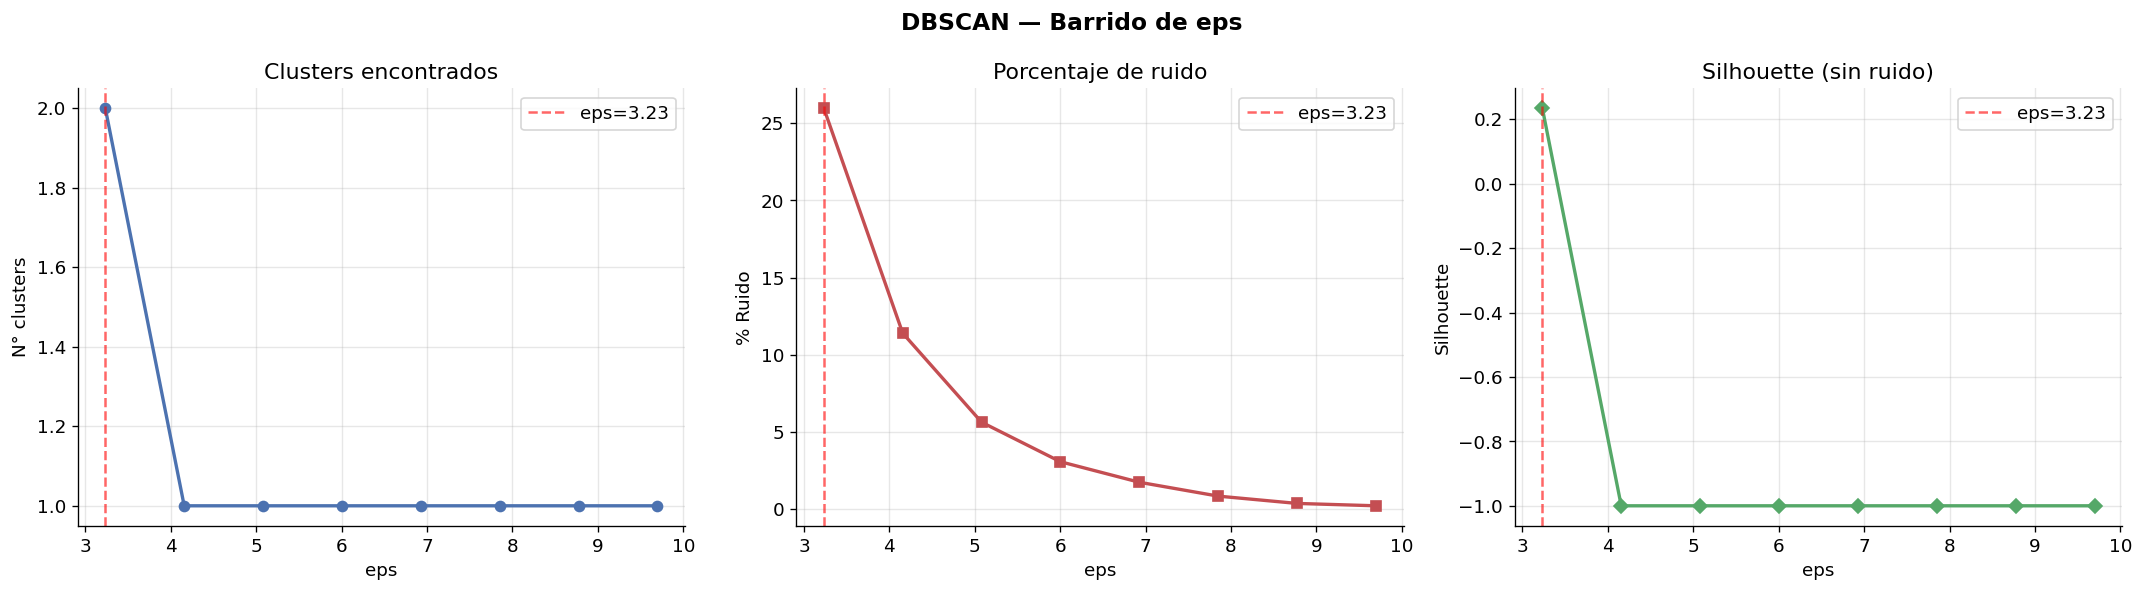

In [127]:
# ── DBSCAN: barrido de eps alrededor del valor automático ──
eps_candidates = np.linspace(EPS_AUTO * 0.5, EPS_AUTO * 1.5, 8)
dbscan_results = []

for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labs = db.fit_predict(X_scaled)
    n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
    n_noise = (labs == -1).sum()
    pct_noise = n_noise / len(labs) * 100
    
    if n_clusters >= 2:
        mask = labs != -1
        sil = silhouette_score(X_scaled[mask], labs[mask], sample_size=5000, random_state=SEED)
    else:
        sil = -1
    
    dbscan_results.append({
        'eps': eps, 'n_clusters': n_clusters, 'n_noise': n_noise,
        'pct_noise': pct_noise, 'silhouette': sil
    })
    print(f'  eps={eps:.3f}  clusters={n_clusters}  ruido={n_noise:,} ({pct_noise:.1f}%)  silhouette={sil:.4f}')

db_df = pd.DataFrame(dbscan_results)

# Seleccionar mejor eps: clusters >= 2 y mejor silhouette
valid = db_df[db_df['n_clusters'] >= 2]
if len(valid) > 0:
    best_idx = valid['silhouette'].idxmax()
    BEST_EPS = valid.loc[best_idx, 'eps']
    print(f'\n→ Mejor eps: {BEST_EPS:.4f} (clusters={int(valid.loc[best_idx, "n_clusters"])}, '
          f'silhouette={valid.loc[best_idx, "silhouette"]:.4f})')
else:
    BEST_EPS = EPS_AUTO
    print(f'\n→ Usando eps automático: {BEST_EPS:.4f}')

# Gráfica de barrido
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DBSCAN — Barrido de eps', fontsize=14, fontweight='bold')

axes[0].plot(db_df['eps'], db_df['n_clusters'], 'o-', color='#4C72B0', lw=2)
axes[0].axvline(x=BEST_EPS, color='red', ls='--', alpha=0.6, label=f'eps={BEST_EPS:.2f}')
axes[0].set_xlabel('eps'); axes[0].set_ylabel('N° clusters'); axes[0].set_title('Clusters encontrados')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(db_df['eps'], db_df['pct_noise'], 's-', color='#C44E52', lw=2)
axes[1].axvline(x=BEST_EPS, color='red', ls='--', alpha=0.6, label=f'eps={BEST_EPS:.2f}')
axes[1].set_xlabel('eps'); axes[1].set_ylabel('% Ruido'); axes[1].set_title('Porcentaje de ruido')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(db_df['eps'], db_df['silhouette'], 'D-', color='#55A868', lw=2)
axes[2].axvline(x=BEST_EPS, color='red', ls='--', alpha=0.6, label=f'eps={BEST_EPS:.2f}')
axes[2].set_xlabel('eps'); axes[2].set_ylabel('Silhouette'); axes[2].set_title('Silhouette (sin ruido)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 Resultado DBSCAN y visualización

DBSCAN (eps=3.2327, min_samples=50)
  Clusters encontrados: 2
  Puntos de ruido: 5,436 (26.0%)
  Distribución: {np.int64(-1): np.int64(5436), np.int64(0): np.int64(11648), np.int64(1): np.int64(3847)}
  Silhouette: 0.2340
  Davies-Bouldin: 1.3489
  Calinski-Harabasz: 4636.5781


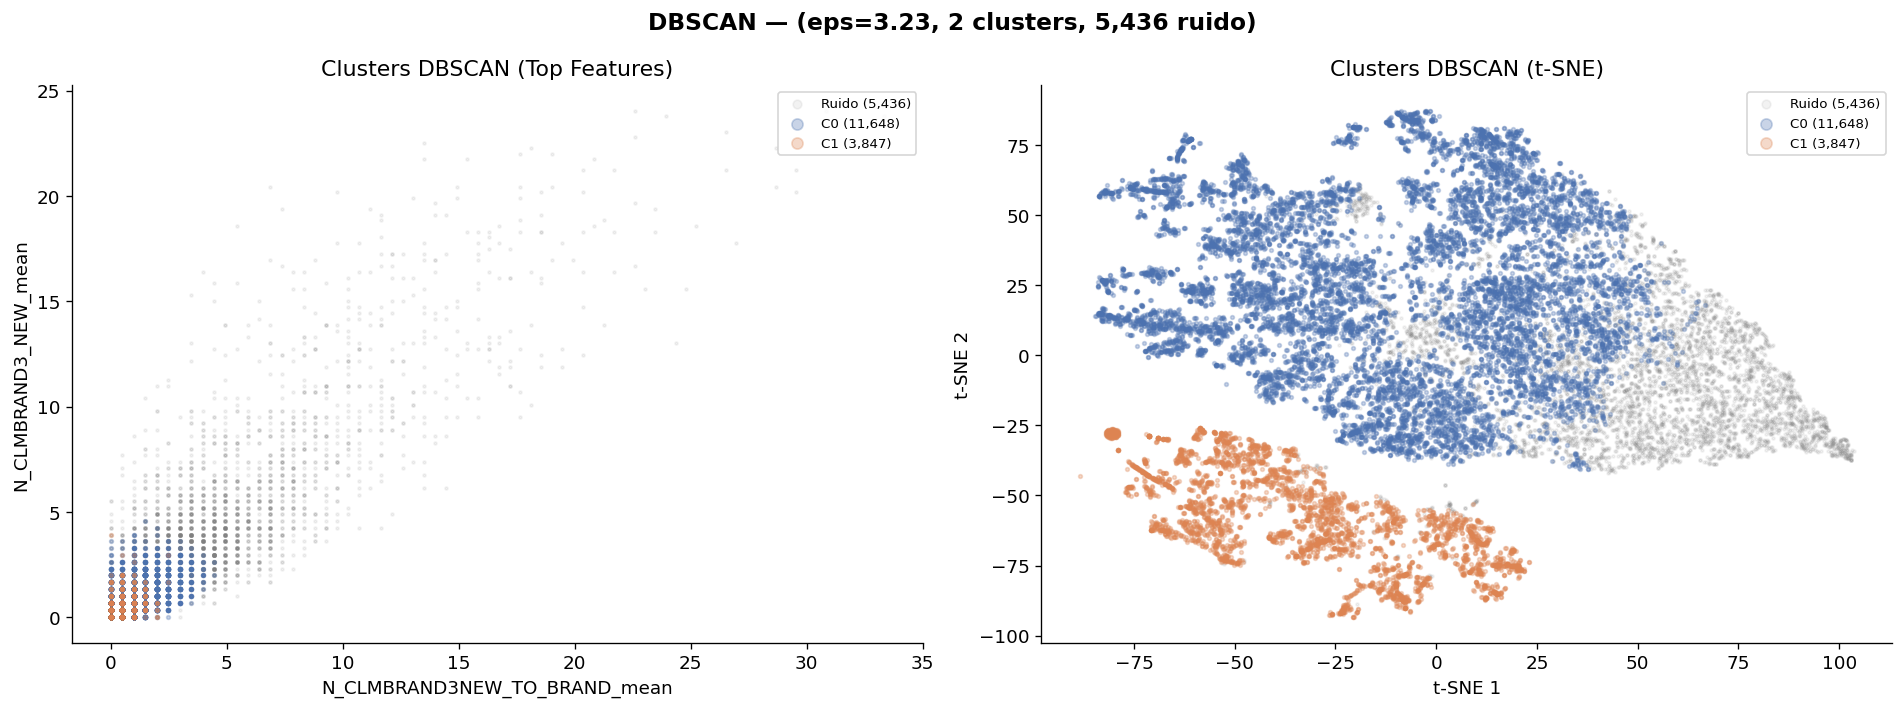

In [128]:
# ── DBSCAN: ejecución final con mejor eps ──
dbscan_final = DBSCAN(eps=BEST_EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan_final.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db = (labels_dbscan == -1).sum()
mask_db = labels_dbscan != -1

print(f'DBSCAN (eps={BEST_EPS:.4f}, min_samples={MIN_SAMPLES})')
print(f'  Clusters encontrados: {n_clusters_db}')
print(f'  Puntos de ruido: {n_noise_db:,} ({n_noise_db/len(labels_dbscan)*100:.1f}%)')
print(f'  Distribución: {dict(zip(*np.unique(labels_dbscan, return_counts=True)))}')

if n_clusters_db >= 2 and mask_db.sum() > 0:
    m_dbscan = {
        'Silhouette': silhouette_score(X_scaled[mask_db], labels_dbscan[mask_db],
                                        sample_size=5000, random_state=SEED),
        'Davies-Bouldin': davies_bouldin_score(X_scaled[mask_db], labels_dbscan[mask_db]),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled[mask_db], labels_dbscan[mask_db]),
    }
    for m, v in m_dbscan.items():
        print(f'  {m}: {v:.4f}')

    all_comparison_rows.append({
        'Algoritmo': 'DBSCAN', 'k': n_clusters_db, 'Tipo': 'auto',
        **m_dbscan
    })
else:
    m_dbscan = None
    print('  (No se pudieron calcular métricas — menos de 2 clusters)')

all_labels[('DBSCAN', n_clusters_db)] = labels_dbscan

# ── Visualización: Top Features + t-SNE ──
X_feat = X_scaled[:, [feat_x_idx, feat_y_idx]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'DBSCAN — (eps={BEST_EPS:.2f}, {n_clusters_db} clusters, {n_noise_db:,} ruido)',
             fontsize=14, fontweight='bold')

unique_labels = sorted(set(labels_dbscan))

# Top Features plot
ax = axes[0]
for label in unique_labels:
    mask = labels_dbscan == label
    if label == -1:
        ax.scatter(X_feat[mask, 0], X_feat[mask, 1], s=3, alpha=0.1,
                   color='gray', label=f'Ruido ({mask.sum():,})')
    else:
        ax.scatter(X_feat[mask, 0], X_feat[mask, 1], s=5, alpha=0.3,
                   color=PALETTE[label % len(PALETTE)], label=f'C{label} ({mask.sum():,})')
ax.set_title('Clusters DBSCAN (Top Features)'); ax.set_xlabel(FEAT_X); ax.set_ylabel(FEAT_Y)
ax.legend(markerscale=3, fontsize=8, loc='upper right')

# t-SNE plot
ax = axes[1]
for label in unique_labels:
    mask = labels_dbscan == label
    if label == -1:
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=3, alpha=0.1,
                   color='gray', label=f'Ruido ({mask.sum():,})')
    else:
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=5, alpha=0.3,
                   color=PALETTE[label % len(PALETTE)], label=f'C{label} ({mask.sum():,})')
ax.set_title('Clusters DBSCAN (t-SNE)'); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(markerscale=3, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## 10. Comparación global — Todos los algoritmos

Tabla consolidada y gráficas comparativas de los 5 algoritmos (incluyendo DBSCAN).

In [129]:
# ── Tabla consolidada ──
comp_global = pd.DataFrame(all_comparison_rows).round(4)

k_opts = {'K-Means': K_OPT_KM, 'K-Medoids': K_OPT_KMED,
          'Hierarchical': K_OPT_HIER, 'GMM': K_OPT_GMM,
          'DBSCAN': n_clusters_db}

print('=' * 80)
print('COMPARACIÓN GLOBAL: Todos los algoritmos')
print('=' * 80)
print(comp_global.to_string(index=False))
print()
print('k/clusters encontrados:')
for algo, k in k_opts.items():
    print(f'  {algo}: k={k}')
comp_global

COMPARACIÓN GLOBAL: Todos los algoritmos
   Algoritmo  k    Tipo  Silhouette  Davies-Bouldin  Calinski-Harabasz
     K-Means  3  óptimo      0.3868          1.0768         13673.9428
   K-Medoids  3  óptimo      0.1958          1.5150          8418.2414
Hierarchical  3  óptimo      0.4210          1.0486         12177.1161
         GMM  4  óptimo      0.2463          3.0275          7356.6468
         GMM  3 negocio      0.2283          1.8660          7257.8471
      DBSCAN  2    auto      0.2340          1.3489          4636.5781

k/clusters encontrados:
  K-Means: k=3
  K-Medoids: k=3
  Hierarchical: k=3
  GMM: k=4
  DBSCAN: k=2


,Algoritmo,k,Tipo,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,óptimo,0.3868,1.0768,13673.9428
1,K-Medoids,3,óptimo,0.1958,1.5150,8418.2414
2,Hierarchical,3,óptimo,0.4210,1.0486,12177.1161
3,GMM,4,óptimo,0.2463,3.0275,7356.6468
4,GMM,3,negocio,0.2283,1.8660,7257.8471
5,DBSCAN,2,auto,0.2340,1.3489,4636.5781


## 11. Validación externa: Cruce con ATSEG

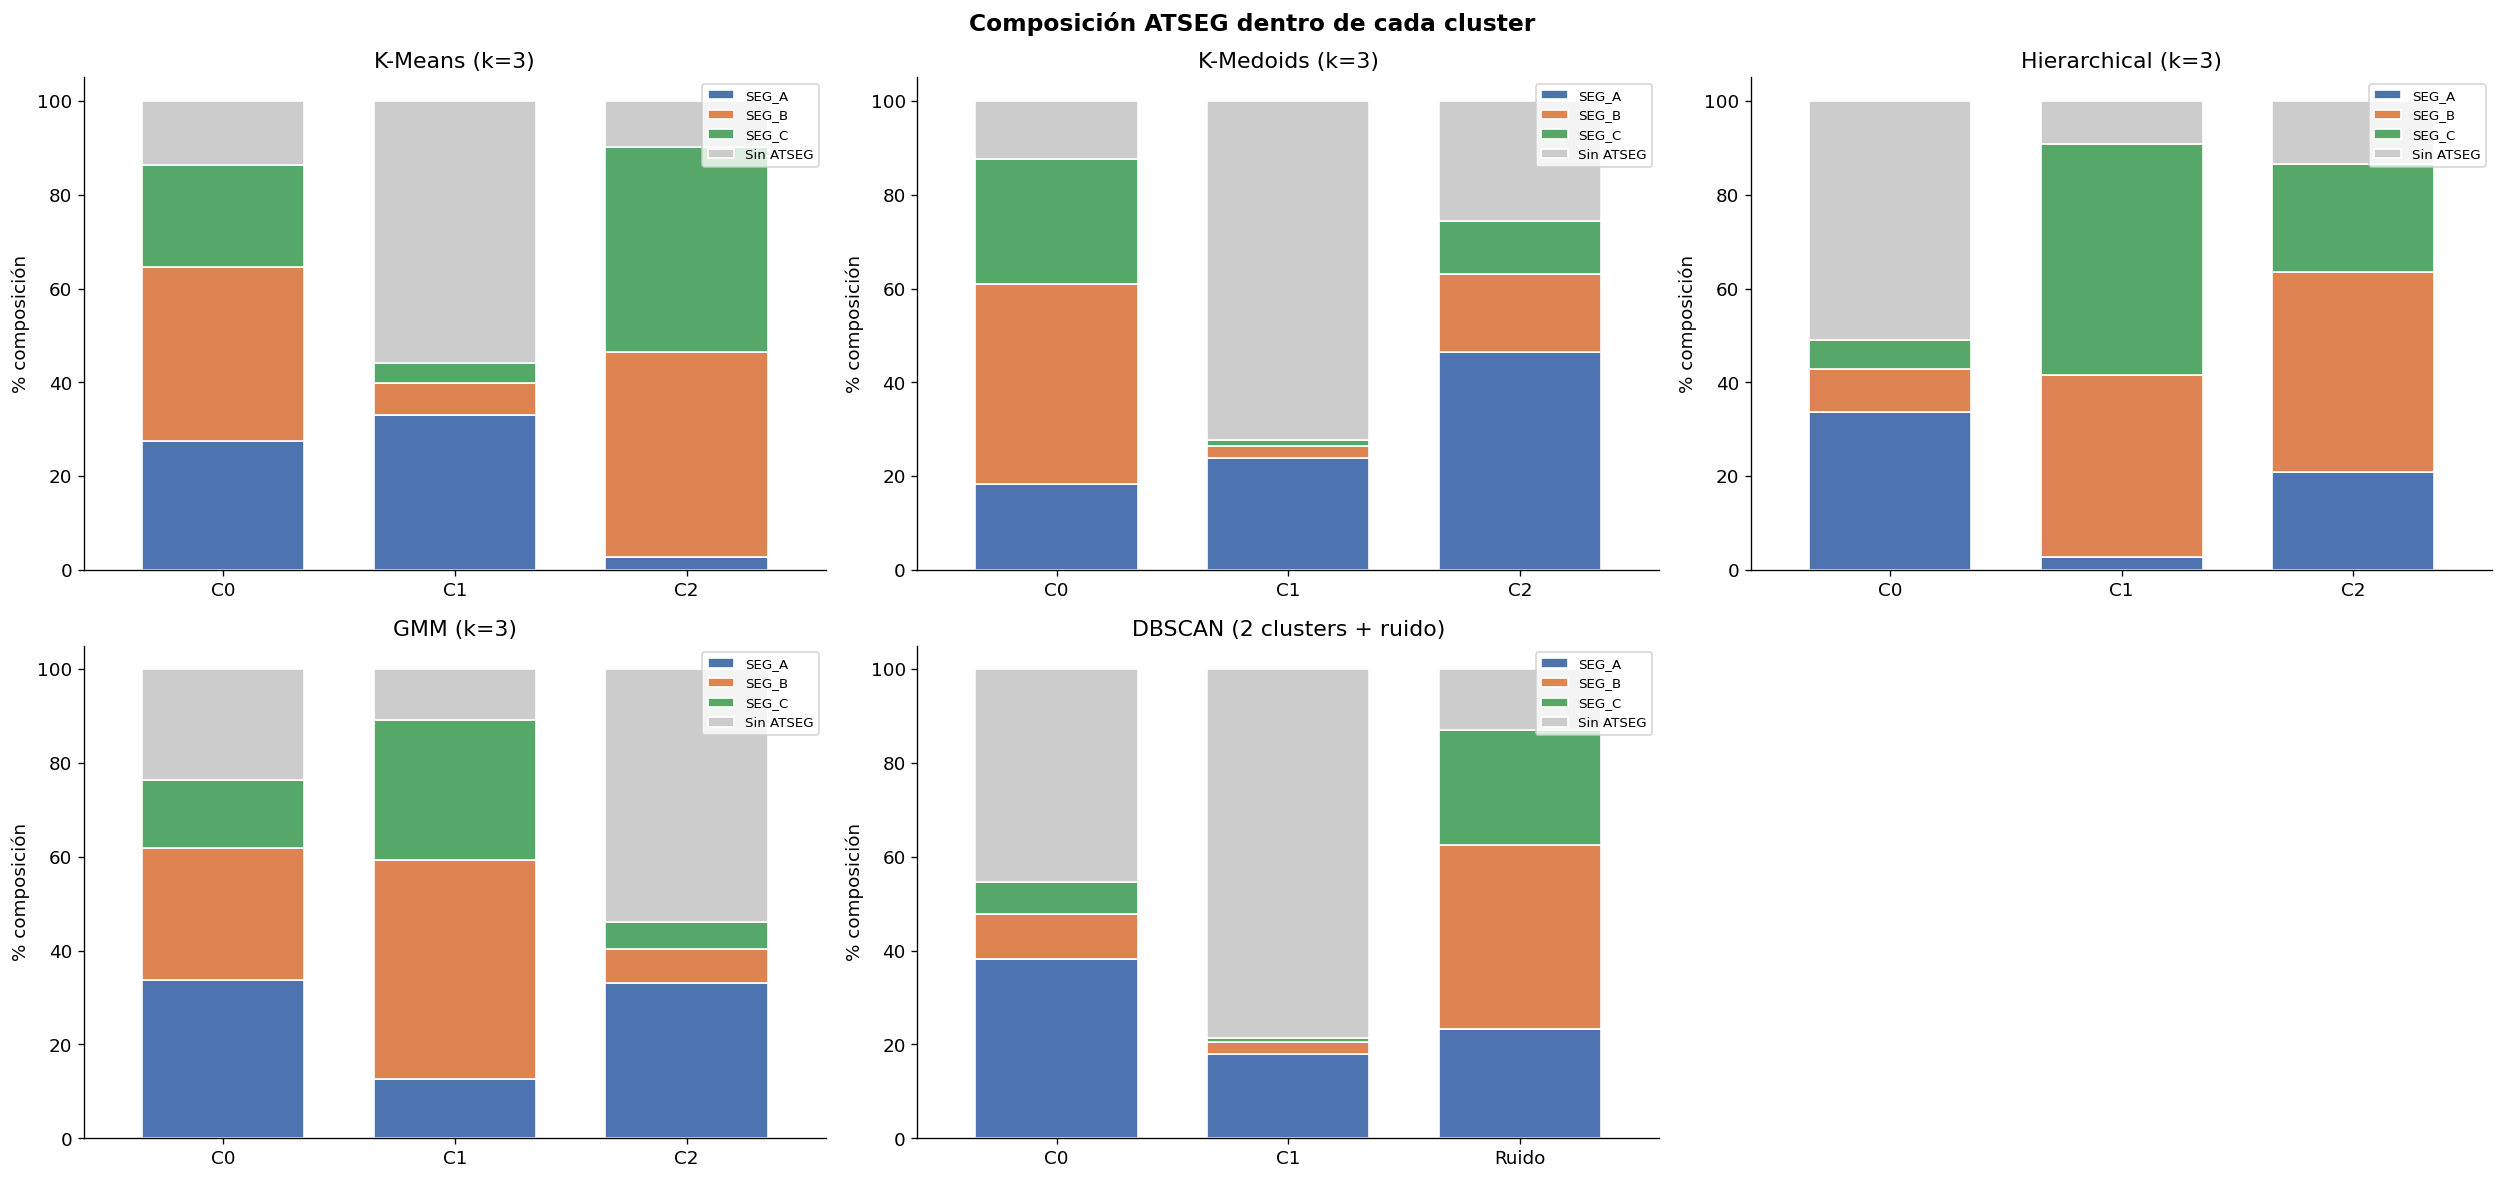

In [130]:
atseg_filled = atseg.fillna('Sin ATSEG')

# ── Construir labels_k3 directamente de las variables de cada algoritmo ──
labels_k3 = {}
if 'labels_km_3' in dir():
    labels_k3['K-Means'] = labels_km_3
if 'labels_kmed_3' in dir():
    labels_k3['K-Medoids'] = labels_kmed_3
if 'labels_hier_3' in dir():
    labels_k3['Hierarchical'] = labels_hier_3
if 'labels_gmm_3' in dir():
    labels_k3['GMM'] = labels_gmm_3

n_panels = len(labels_k3) + (1 if 'labels_dbscan' in dir() else 0)
ncols = min(n_panels, 3)
nrows = (n_panels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
fig.suptitle('Composición ATSEG dentro de cada cluster',
             fontsize=14, fontweight='bold')

ax_list = np.array(axes).flatten() if n_panels > 1 else [axes]

for idx, (name, labels) in enumerate(labels_k3.items()):
    ax = ax_list[idx]
    ct = pd.crosstab(
        pd.Series([f'C{l}' for l in labels], name='Cluster'),
        atseg_filled,
        normalize='index'
    ) * 100
    ct = ct[[c for c in ['SEG_A', 'SEG_B', 'SEG_C', 'Sin ATSEG'] if c in ct.columns]]
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[PALETTE[0], PALETTE[1], PALETTE[2], '#CCCCCC'],
            edgecolor='white', width=0.7)
    ax.set_title(f'{name} (k=3)'); ax.set_ylabel('% composición')
    ax.set_xlabel(''); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, 105)

# DBSCAN
if 'labels_dbscan' in dir():
    ax = ax_list[len(labels_k3)]
    ct_db = pd.crosstab(
        pd.Series([f'Ruido' if l == -1 else f'C{l}' for l in labels_dbscan], name='Cluster'),
        atseg_filled,
        normalize='index'
    ) * 100
    ct_db = ct_db[[c for c in ['SEG_A', 'SEG_B', 'SEG_C', 'Sin ATSEG'] if c in ct_db.columns]]
    ct_db.plot(kind='bar', stacked=True, ax=ax,
               color=[PALETTE[0], PALETTE[1], PALETTE[2], '#CCCCCC'],
               edgecolor='white', width=0.7)
    ax.set_title(f'DBSCAN ({n_clusters_db} clusters + ruido)'); ax.set_ylabel('% composición')
    ax.set_xlabel(''); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, 105)

for idx in range(n_panels, len(ax_list)):
    ax_list[idx].set_visible(False)

plt.tight_layout()
plt.savefig('atseg_composition_k3.png', bbox_inches='tight', dpi=130)
plt.show()

In [131]:
# ── Tablas de contingencia numéricas ──
for name, labels in labels_k3.items():
    ct = pd.crosstab(
        pd.Series([f'C{l}' for l in labels], name='Cluster'),
        atseg_filled,
        margins=True
    )
    print(f'\n{name} (k=3):')
    print(ct.to_string())

# DBSCAN
if 'labels_dbscan' in dir():
    ct_dbscan = pd.crosstab(
        pd.Series([f'Ruido' if l == -1 else f'C{l}' for l in labels_dbscan], name='Cluster'),
        atseg_filled,
        margins=True
    )
    print(f'\nDBSCAN ({n_clusters_db} clusters + ruido):')
    print(ct_dbscan.to_string())


K-Means (k=3):
ATSEG_first  SEG_A  SEG_B  SEG_C  Sin ATSEG    All
Cluster                                           
C0            1518   2040   1194        754   5506
C1            4867    992    631       8207  14697
C2              21    317    319         71    728
All           6406   3349   2144       9032  20931

K-Medoids (k=3):
ATSEG_first  SEG_A  SEG_B  SEG_C  Sin ATSEG    All
Cluster                                           
C0             817   1900   1185        551   4453
C1            2180    231    125       6600   9136
C2            3409   1218    834       1881   7342
All           6406   3349   2144       9032  20931

Hierarchical (k=3):
ATSEG_first  SEG_A  SEG_B  SEG_C  Sin ATSEG    All
Cluster                                           
C0            5593   1519   1007       8472  16591
C1              15    205    261         49    530
C2             798   1625    876        511   3810
All           6406   3349   2144       9032  20931

GMM (k=3):
ATSEG_first  SE

### 11.1 Concordancia cuantitativa (ARI, NMI, V-Measure)

In [154]:
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_completeness_v_measure)

# ── Only doctors with known ATSEG ──
has_atseg = atseg.notna()
atseg_true = atseg[has_atseg].values
print(f'Doctors with assigned ATSEG: {has_atseg.sum():,} / {len(atseg):,} '
      f'({has_atseg.sum()/len(atseg)*100:.1f}%)\n')

# ── Build labels dict directly ──
algos_conc = {}
if 'labels_km_3' in dir():
    algos_conc['K-Means (k=3)'] = labels_km_3
if 'labels_km_opt' in dir() and K_OPT_KM != 3:
    algos_conc[f'K-Means (k={K_OPT_KM})'] = labels_km_opt
if 'labels_kmed_3' in dir():
    algos_conc['K-Medoids (k=3)'] = labels_kmed_3
if 'labels_kmed_opt' in dir() and K_OPT_KMED != 3:
    algos_conc[f'K-Medoids (k={K_OPT_KMED})'] = labels_kmed_opt
if 'labels_hier_3' in dir():
    algos_conc['Hierarchical (k=3)'] = labels_hier_3
if 'labels_hier_opt' in dir() and K_OPT_HIER != 3:
    algos_conc[f'Hierarchical (k={K_OPT_HIER})'] = labels_hier_opt
if 'labels_gmm_3' in dir():
    algos_conc['GMM (k=3)'] = labels_gmm_3
if 'labels_gmm_opt' in dir() and K_OPT_GMM != 3:
    algos_conc[f'GMM (k={K_OPT_GMM})'] = labels_gmm_opt

concordance_rows = []
for name, labels in algos_conc.items():
    labs_sub = labels[has_atseg]
    ari = adjusted_rand_score(atseg_true, labs_sub)
    nmi = normalized_mutual_info_score(atseg_true, labs_sub)
    homo, comp, vm = homogeneity_completeness_v_measure(atseg_true, labs_sub)
    concordance_rows.append({
        'Algorithm': name, 'ARI': ari, 'NMI': nmi,
        'Homogeneity': homo, 'Completeness': comp, 'V-Measure': vm
    })

# DBSCAN: exclude noise
if 'labels_dbscan' in dir():
    mask_db_atseg = has_atseg & (labels_dbscan != -1)
    if mask_db_atseg.sum() > 10:
        ari_db = adjusted_rand_score(atseg[mask_db_atseg].values, labels_dbscan[mask_db_atseg])
        nmi_db = normalized_mutual_info_score(atseg[mask_db_atseg].values, labels_dbscan[mask_db_atseg])
        h_db, c_db, v_db = homogeneity_completeness_v_measure(atseg[mask_db_atseg].values, labels_dbscan[mask_db_atseg])
        concordance_rows.append({
            'Algorithm': f'DBSCAN ({n_clusters_db}c)', 'ARI': ari_db, 'NMI': nmi_db,
            'Homogeneity': h_db, 'Completeness': c_db, 'V-Measure': v_db
        })

df_conc = pd.DataFrame(concordance_rows).round(4)
df_conc = df_conc.sort_values('ARI', ascending=False).reset_index(drop=True)
print('CLUSTER vs ATSEG CONCORDANCE')
print(df_conc.to_string(index=False))
df_conc

Doctors with assigned ATSEG: 11,899 / 20,931 (56.8%)

CLUSTER vs ATSEG CONCORDANCE
         Algorithm     ARI    NMI  Homogeneity  Completeness  V-Measure
Hierarchical (k=3)  0.2173 0.1274       0.1113        0.1490     0.1274
     K-Means (k=3)  0.2012 0.1369       0.1272        0.1482     0.1369
         GMM (k=3)  0.1968 0.1129       0.1121        0.1137     0.1129
         GMM (k=4)  0.1522 0.1107       0.1202        0.1027     0.1107
   K-Medoids (k=3)  0.1084 0.1286       0.1320        0.1253     0.1286
       DBSCAN (2c) -0.0503 0.0103       0.0075        0.0165     0.0103


,Algorithm,ARI,NMI,Homogeneity,Completeness,V-Measure
0,Hierarchical (k=3),0.2173,0.1274,0.1113,0.1490,0.1274
1,K-Means (k=3),0.2012,0.1369,0.1272,0.1482,0.1369
2,GMM (k=3),0.1968,0.1129,0.1121,0.1137,0.1129
3,GMM (k=4),0.1522,0.1107,0.1202,0.1027,0.1107
4,K-Medoids (k=3),0.1084,0.1286,0.1320,0.1253,0.1286
5,DBSCAN (2c),-0.0503,0.0103,0.0075,0.0165,0.0103


### 11.2 Top Features lado a lado: ATSEG vs Clusters

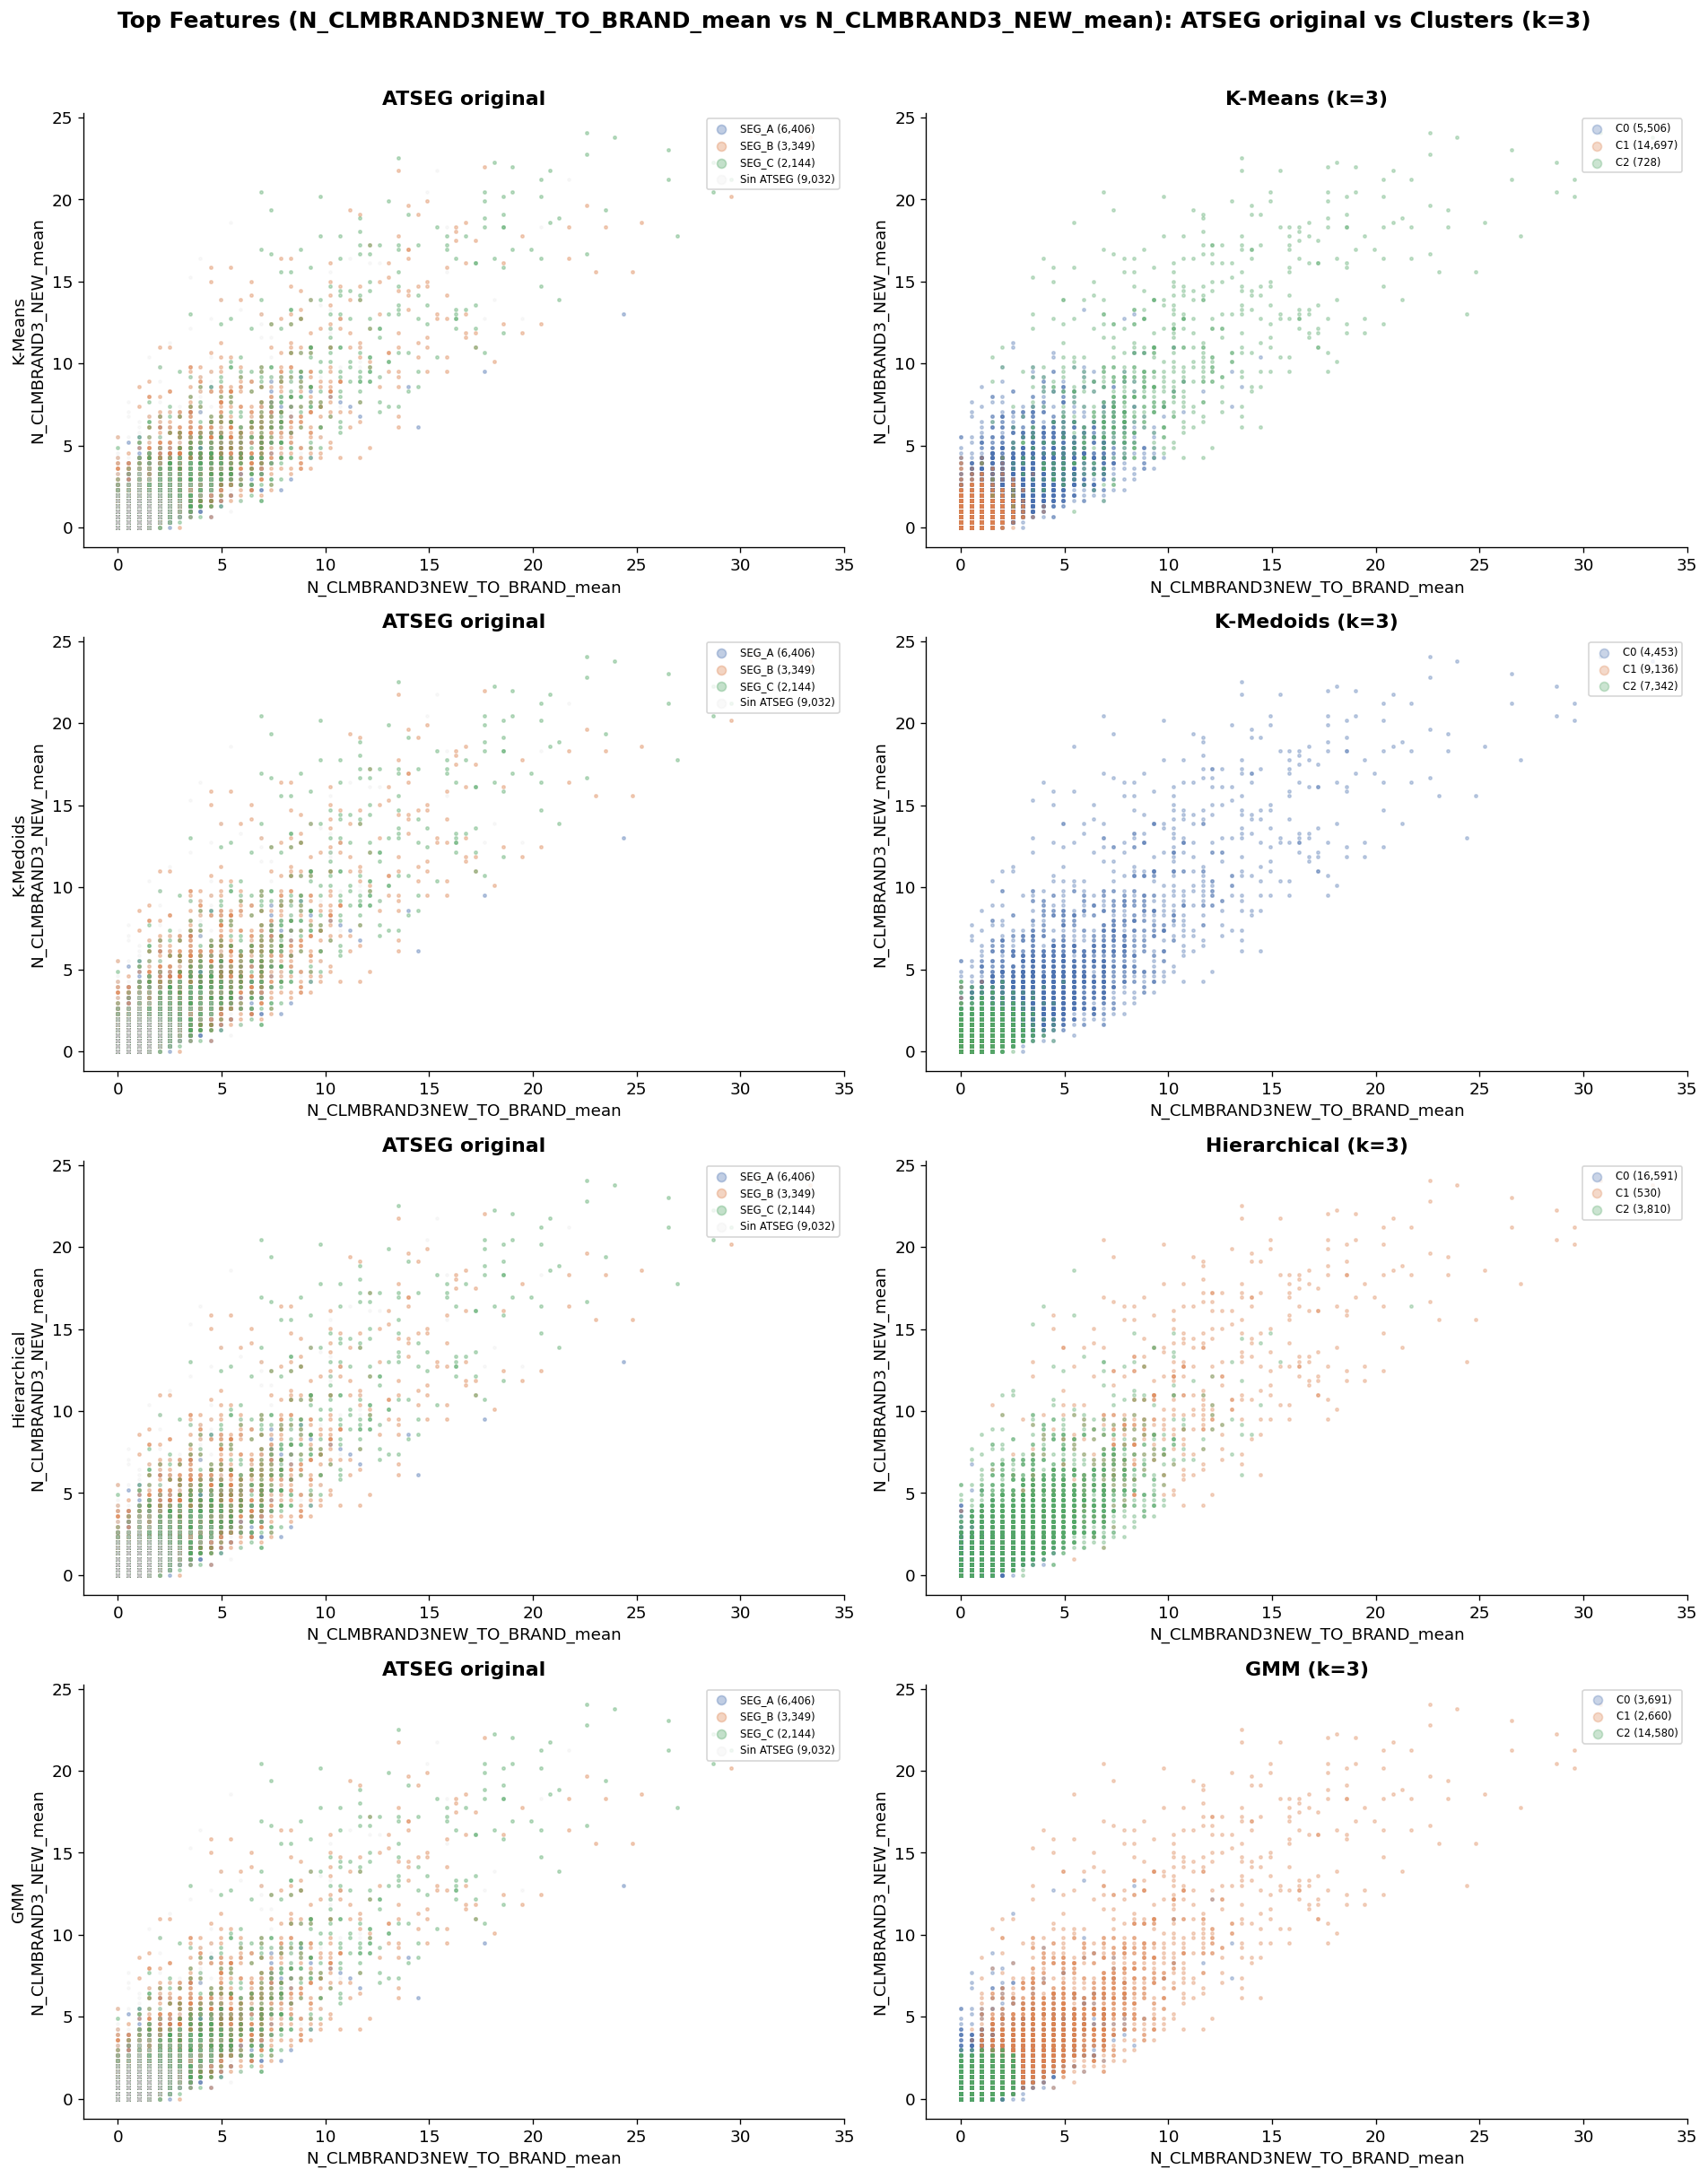

In [133]:
# ── Top Features lado a lado: ATSEG vs cada algoritmo (k=3) ──
atseg_order = ['SEG_A', 'SEG_B', 'SEG_C', 'Sin ATSEG']
atseg_colors = {'SEG_A': PALETTE[0], 'SEG_B': PALETTE[1],
                'SEG_C': PALETTE[2], 'Sin ATSEG': '#CCCCCC'}
atseg_plot = atseg.fillna('Sin ATSEG')
X_feat = X_scaled[:, [feat_x_idx, feat_y_idx]]

n_algos = len(labels_k3)
if n_algos > 0:
    fig, axes = plt.subplots(n_algos, 2, figsize=(16, 5 * n_algos))
    if n_algos == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle(f'Top Features ({FEAT_X} vs {FEAT_Y}): ATSEG original vs Clusters (k=3)',
                 fontsize=15, fontweight='bold', y=1.01)

    for row, (algo_name, labels) in enumerate(labels_k3.items()):
        ax_l = axes[row, 0]
        for seg in atseg_order:
            mask = atseg_plot == seg
            alpha = 0.1 if seg == 'Sin ATSEG' else 0.35
            ax_l.scatter(X_feat[mask, 0], X_feat[mask, 1], s=4, alpha=alpha,
                         color=atseg_colors[seg], label=f'{seg} ({mask.sum():,})')
        ax_l.set_title('ATSEG original', fontweight='bold')
        ax_l.set_xlabel(FEAT_X); ax_l.set_ylabel(f'{algo_name}\n{FEAT_Y}')
        ax_l.legend(markerscale=3, fontsize=7, loc='upper right')

        ax_r = axes[row, 1]
        for c in sorted(set(labels)):
            mask = labels == c
            ax_r.scatter(X_feat[mask, 0], X_feat[mask, 1], s=4, alpha=0.3,
                         color=PALETTE[c % len(PALETTE)], label=f'C{c} ({mask.sum():,})')
        ax_r.set_title(f'{algo_name} (k=3)', fontweight='bold')
        ax_r.set_xlabel(FEAT_X); ax_r.set_ylabel(FEAT_Y)
        ax_r.legend(markerscale=3, fontsize=7, loc='upper right')

    plt.tight_layout()
    plt.savefig('features_atseg_vs_clusters.png', bbox_inches='tight', dpi=130)
    plt.show()

### 11.3 Perspectiva inversa: ATSEG → Clusters

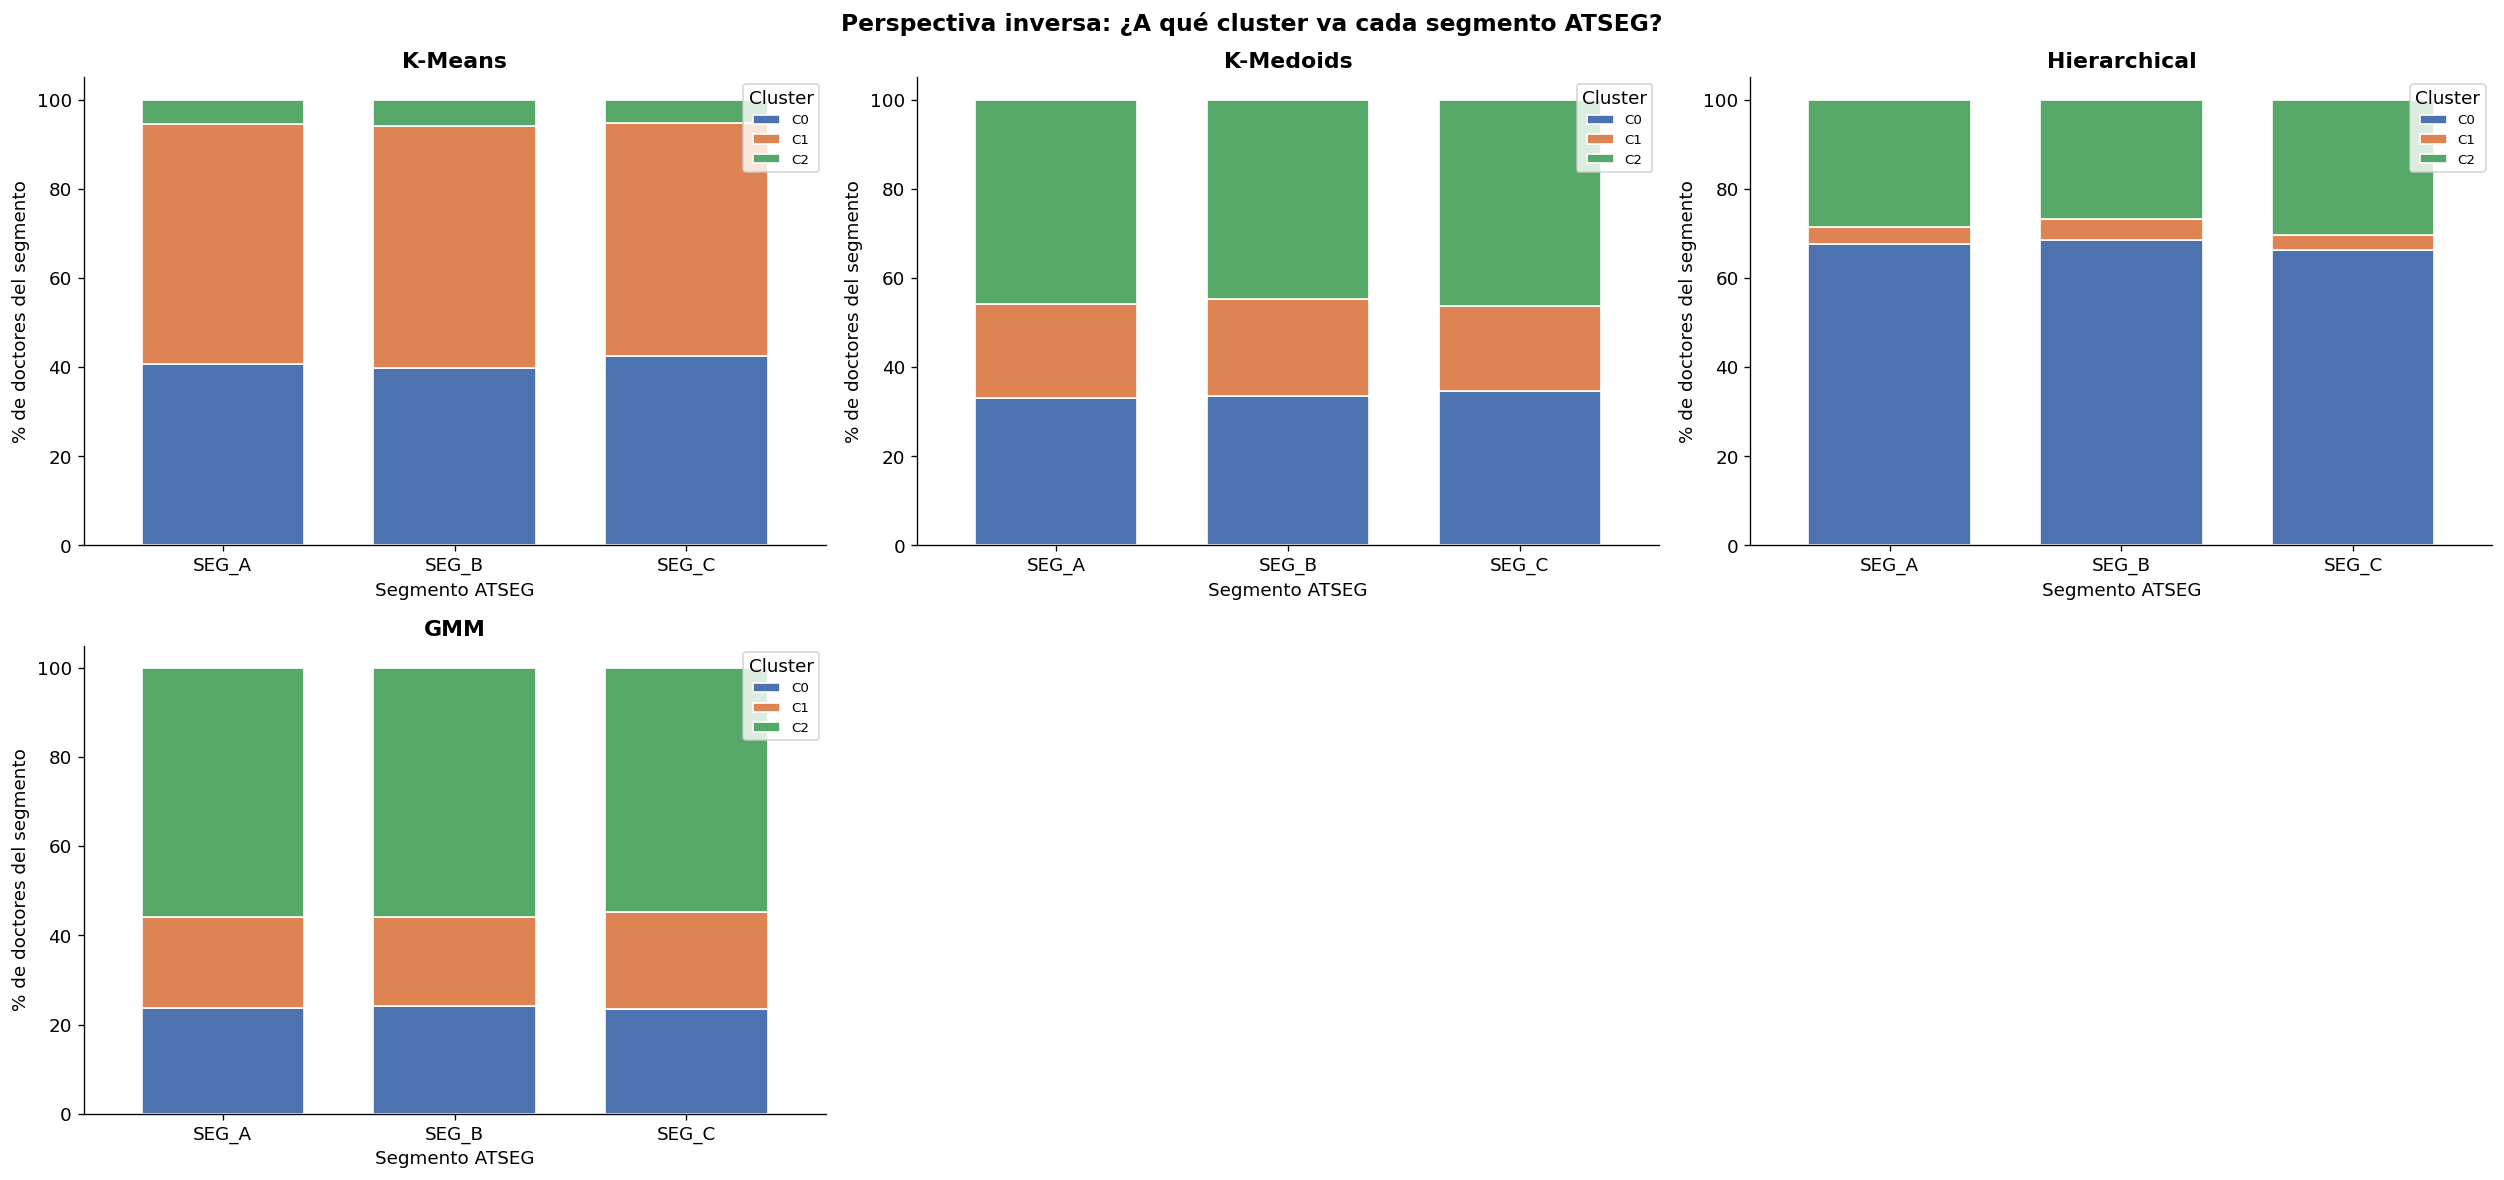

In [134]:
# ── Perspectiva inversa: para cada ATSEG, a qué cluster van ──
has_atseg_mask = atseg.notna()
n_k3 = len(labels_k3)

if n_k3 > 0:
    ncols_r = min(n_k3, 3)
    nrows_r = (n_k3 + ncols_r - 1) // ncols_r
    fig, axes = plt.subplots(nrows_r, ncols_r, figsize=(7 * ncols_r, 5 * nrows_r))
    fig.suptitle('Perspectiva inversa: ¿A qué cluster va cada segmento ATSEG?',
                 fontsize=14, fontweight='bold')

    ax_list = np.array(axes).flatten() if n_k3 > 1 else [axes]

    for idx, (algo_name, labels) in enumerate(labels_k3.items()):
        ax = ax_list[idx]
        ct = pd.crosstab(
            atseg[has_atseg_mask],
            pd.Series([f'C{l}' for l in labels[has_atseg_mask]], name='Cluster'),
            normalize='index'
        ) * 100
        ct = ct[sorted(ct.columns)]
        ct.plot(kind='bar', stacked=True, ax=ax,
                color=PALETTE[:len(ct.columns)], edgecolor='white', width=0.7)
        ax.set_title(algo_name, fontweight='bold')
        ax.set_ylabel('% de doctores del segmento')
        ax.set_xlabel('Segmento ATSEG')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.legend(title='Cluster', fontsize=8, loc='upper right')
        ax.set_ylim(0, 105)

    for idx in range(n_k3, len(ax_list)):
        ax_list[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('atseg_to_clusters_reverse.png', bbox_inches='tight', dpi=130)
    plt.show()

### 11.4 Bubble chart: Cluster x ATSEG

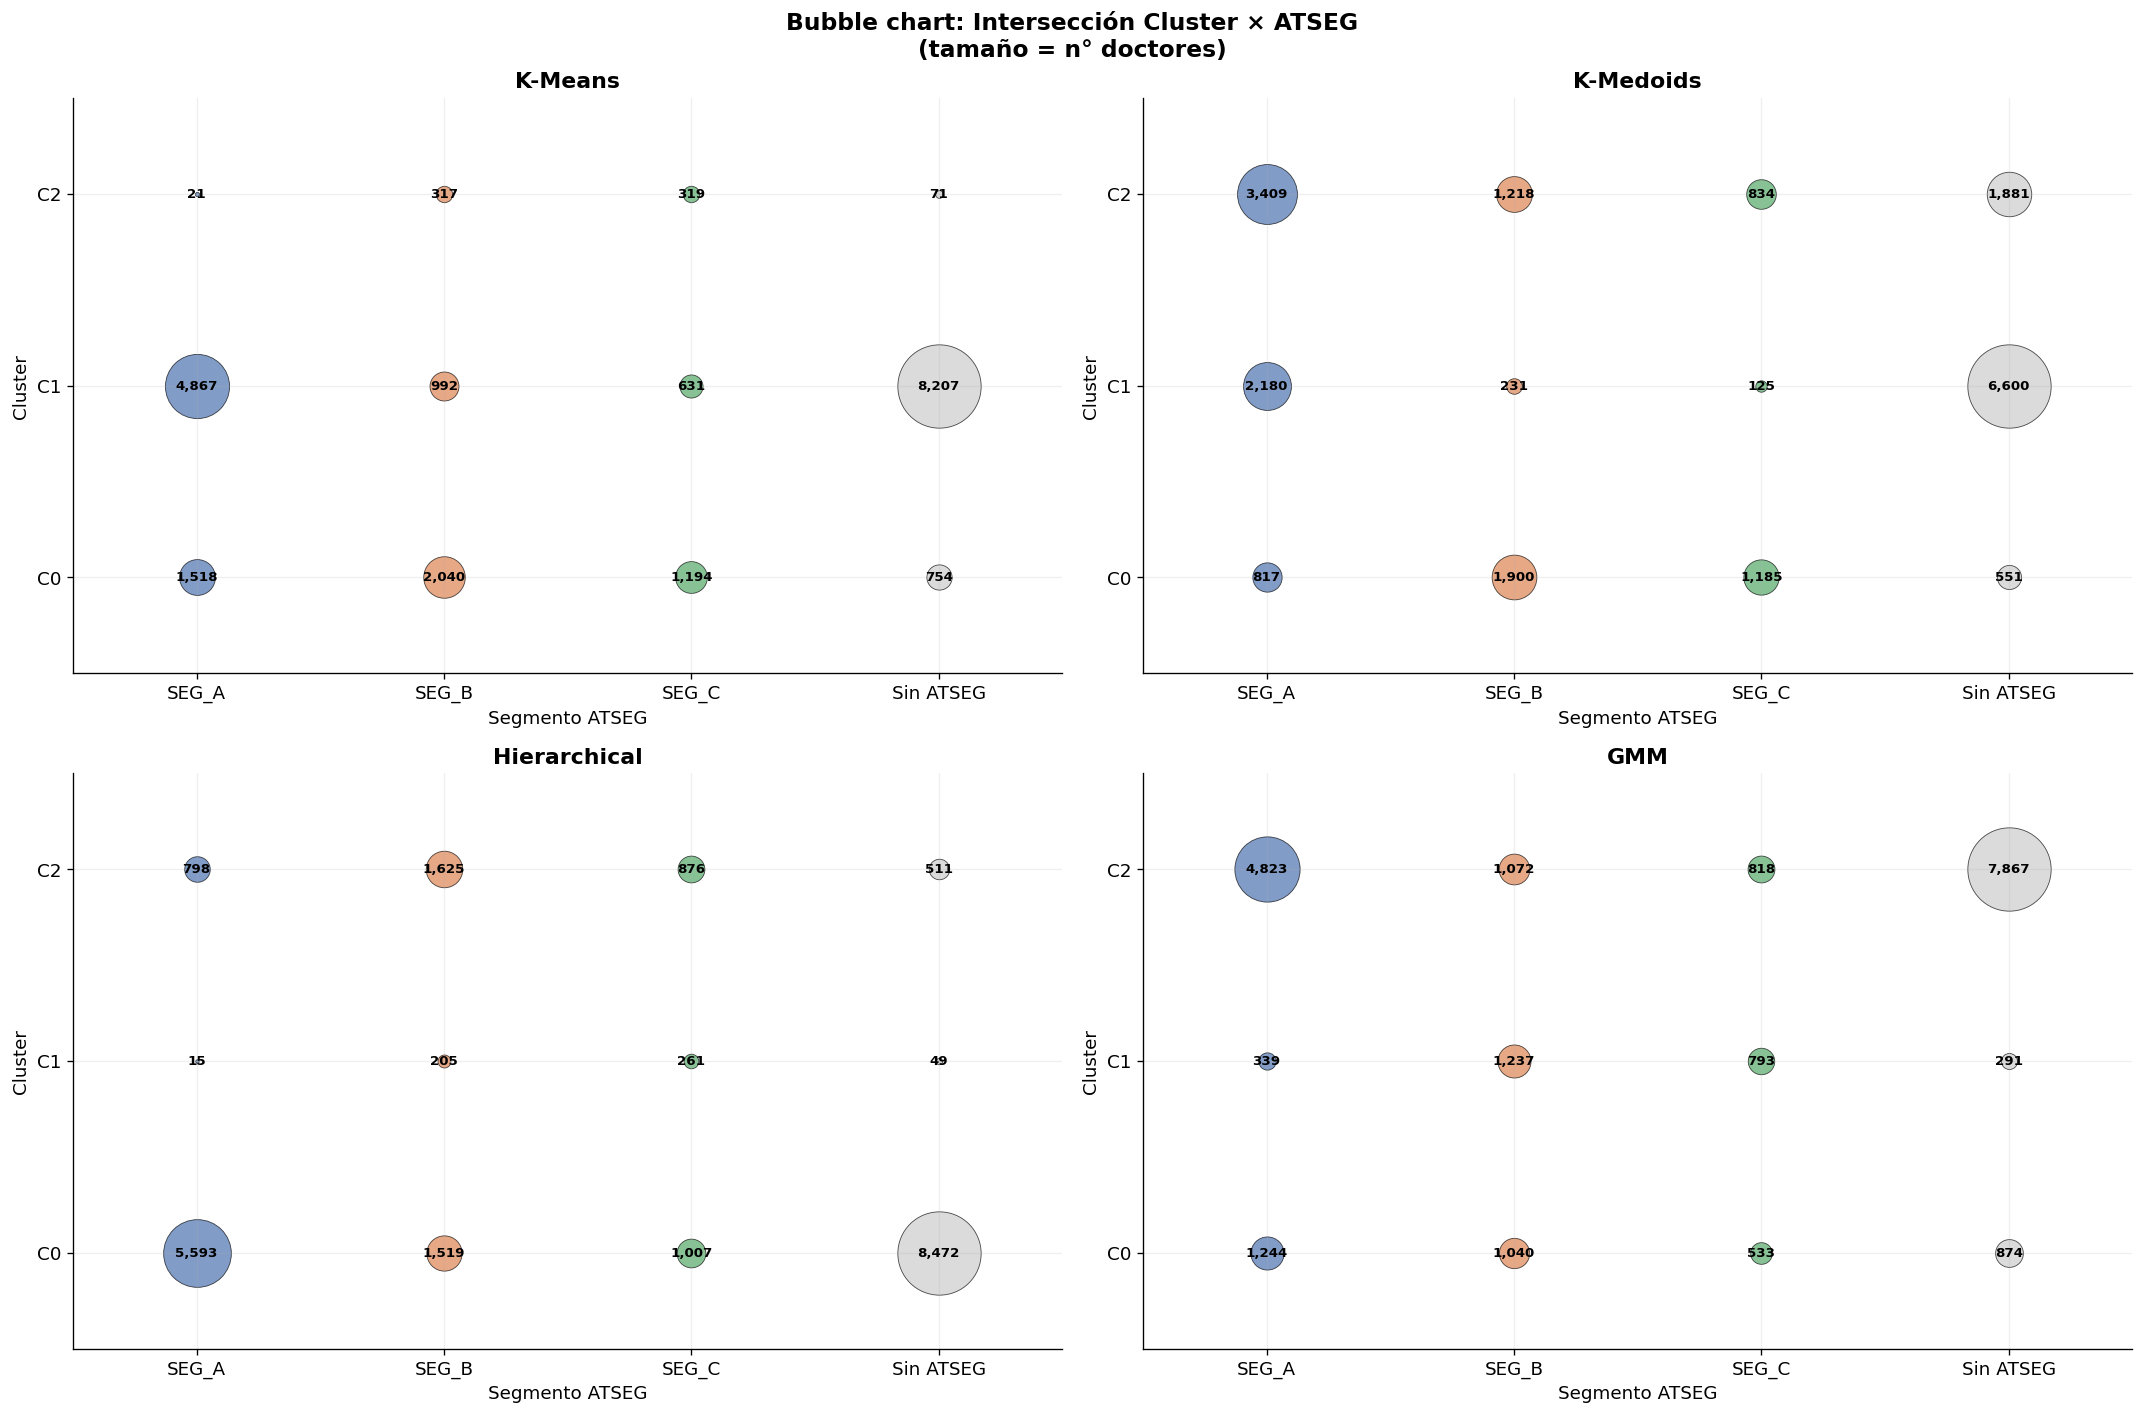

In [135]:
# ── Bubble chart: intersección Cluster × ATSEG ──
n_b = len(labels_k3)
if n_b > 0:
    ncols_b = min(n_b, 2)
    nrows_b = (n_b + ncols_b - 1) // ncols_b
    fig, axes = plt.subplots(nrows_b, ncols_b, figsize=(9 * ncols_b, 6 * nrows_b))
    fig.suptitle('Bubble chart: Intersección Cluster × ATSEG\n(tamaño = n° doctores)',
                 fontsize=14, fontweight='bold')

    ax_list = np.array(axes).flatten() if n_b > 1 else [axes]

    for idx, (algo_name, labels) in enumerate(labels_k3.items()):
        ax = ax_list[idx]
        labs_str = pd.Series([f'C{l}' for l in labels])
        atseg_str = atseg.fillna('Sin ATSEG')
        ct = pd.crosstab(labs_str, atseg_str)
        clusters_sorted = sorted(ct.index)
        segs = [s for s in ['SEG_A', 'SEG_B', 'SEG_C', 'Sin ATSEG'] if s in ct.columns]
        max_val = ct.values.max()

        for i, cluster in enumerate(clusters_sorted):
            for j, seg in enumerate(segs):
                val = ct.loc[cluster, seg] if seg in ct.columns else 0
                size = (val / max_val) * 2500 if max_val > 0 else 0
                color = atseg_colors.get(seg, '#CCCCCC')
                ax.scatter(j, i, s=size, color=color, alpha=0.7,
                           edgecolors='black', linewidths=0.5)
                if val > 0:
                    ax.annotate(f'{val:,}', (j, i), ha='center', va='center',
                                fontsize=8, fontweight='bold')

        ax.set_xticks(range(len(segs))); ax.set_xticklabels(segs)
        ax.set_yticks(range(len(clusters_sorted))); ax.set_yticklabels(clusters_sorted)
        ax.set_xlabel('Segmento ATSEG'); ax.set_ylabel('Cluster')
        ax.set_title(algo_name, fontweight='bold')
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.5, len(segs) - 0.5)
        ax.set_ylim(-0.5, len(clusters_sorted) - 0.5)

    for idx in range(n_b, len(ax_list)):
        ax_list[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('bubble_cluster_atseg.png', bbox_inches='tight', dpi=130)
    plt.show()

### 11.5 Diagrama de flujo: ATSEG → Clusters

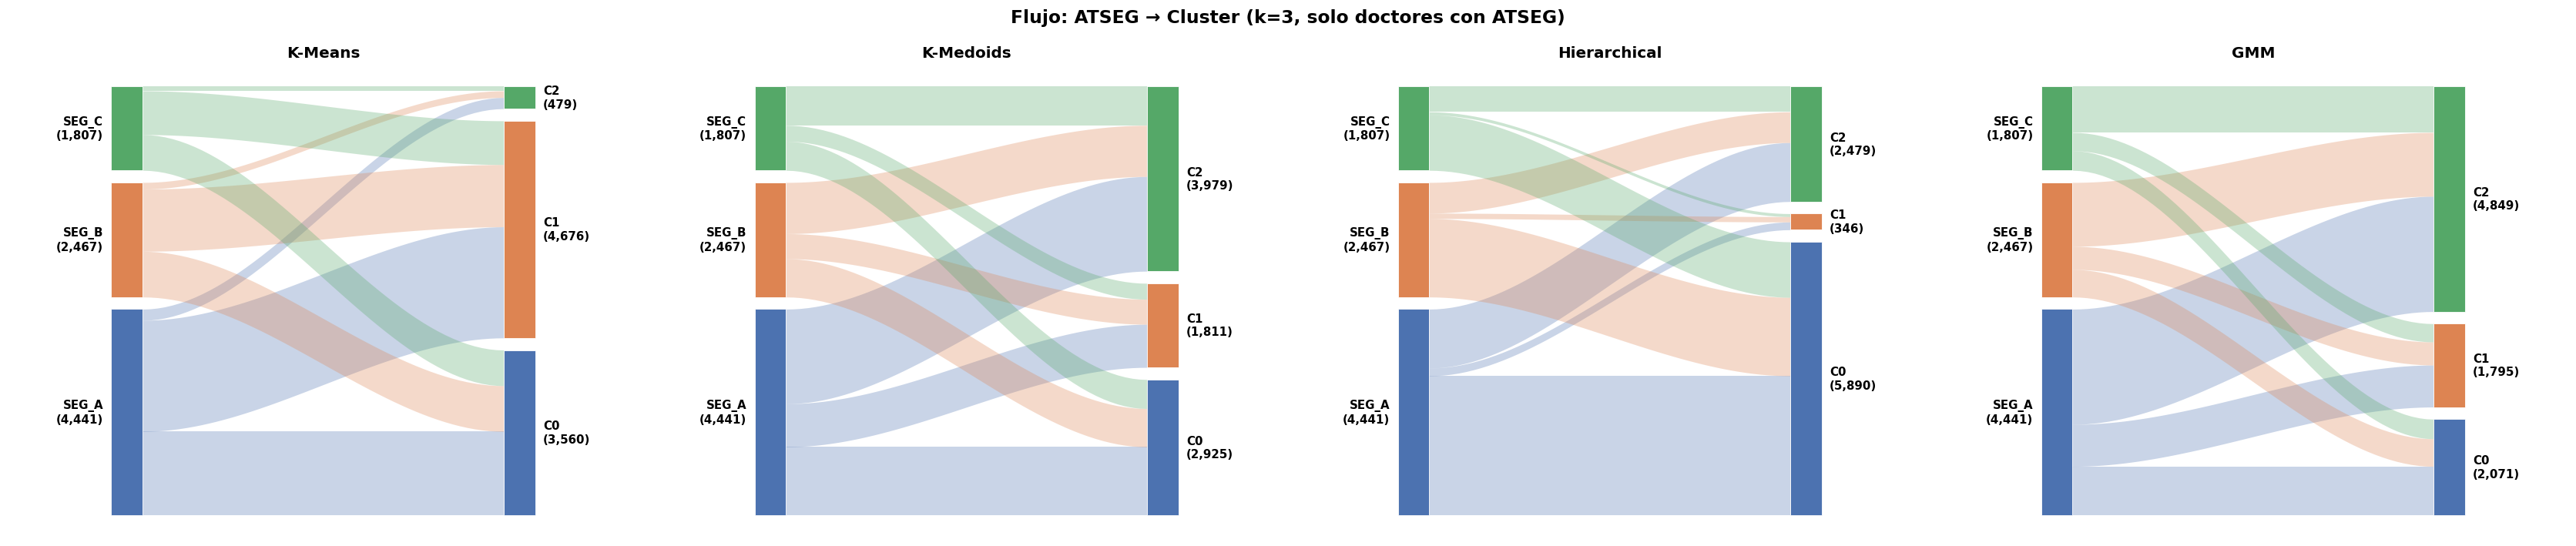

In [136]:
# ── Diagrama de flujo tipo Sankey: ATSEG → Clusters ──
def draw_sankey(ax, ct, left_labels, right_labels, left_colors, right_colors, title):
    total = ct.values.sum()
    left_totals = ct.sum(axis=1).values
    right_totals = ct.sum(axis=0).values
    gap = 0.03
    left_heights = left_totals / total
    right_heights = right_totals / total

    left_y, y = [], 0
    for h in left_heights:
        left_y.append(y); y += h + gap
    right_y, y = [], 0
    for h in right_heights:
        right_y.append(y); y += h + gap

    x_left, x_right = 0.0, 1.0

    for i, (label, height) in enumerate(zip(left_labels, left_heights)):
        ax.barh(left_y[i] + height/2, 0.08, height=height, left=x_left-0.04,
                color=left_colors[i], edgecolor='white', linewidth=0.5, zorder=3)
        ax.text(x_left-0.06, left_y[i]+height/2, f'{label}\n({left_totals[i]:,.0f})',
                ha='right', va='center', fontsize=9, fontweight='bold')

    for j, (label, height) in enumerate(zip(right_labels, right_heights)):
        ax.barh(right_y[j] + height/2, 0.08, height=height, left=x_right-0.04,
                color=right_colors[j], edgecolor='white', linewidth=0.5, zorder=3)
        ax.text(x_right+0.06, right_y[j]+height/2, f'{label}\n({right_totals[j]:,.0f})',
                ha='left', va='center', fontsize=9, fontweight='bold')

    left_cursors = list(left_y)
    right_cursors = list(right_y)
    for i in range(len(left_labels)):
        for j in range(len(right_labels)):
            flow = ct.iloc[i, j]
            if flow == 0: continue
            flow_h = flow / total
            y_start, y_end = left_cursors[i], right_cursors[j]
            xs = np.linspace(x_left+0.04, x_right-0.04, 50)
            t = (xs - xs[0]) / (xs[-1] - xs[0])
            s = 3*t**2 - 2*t**3
            y_bot = y_start + s * (y_end - y_start)
            y_top = (y_start + flow_h) + s * ((y_end + flow_h) - (y_start + flow_h))
            ax.fill_between(xs, y_bot, y_top, alpha=0.3, color=left_colors[i], linewidth=0)
            left_cursors[i] += flow_h
            right_cursors[j] += flow_h

    ax.set_xlim(-0.3, 1.3); ax.set_title(title, fontsize=12, fontweight='bold'); ax.axis('off')

# Generar
n_s = len(labels_k3)
if n_s > 0:
    fig, axes = plt.subplots(1, n_s, figsize=(7*n_s, 6))
    if n_s == 1: axes = [axes]
    fig.suptitle('Flujo: ATSEG → Cluster (k=3, solo doctores con ATSEG)',
                 fontsize=14, fontweight='bold')

    for idx, (algo_name, labels) in enumerate(labels_k3.items()):
        mask = atseg.notna()
        ct = pd.crosstab(atseg[mask], pd.Series([f'C{l}' for l in labels[mask]]))
        ct = ct.loc[['SEG_A','SEG_B','SEG_C']]
        ct = ct[sorted(ct.columns)]
        draw_sankey(axes[idx], ct, list(ct.index), list(ct.columns),
                    [PALETTE[0], PALETTE[1], PALETTE[2]],
                    [PALETTE[i%len(PALETTE)] for i in range(len(ct.columns))],
                    algo_name)

    plt.tight_layout()
    plt.savefig('sankey_atseg_clusters.png', bbox_inches='tight', dpi=130)
    plt.show()

### 11.6 Matriz de confusión: Clusters vs ATSEG

Matriz de confusión normalizada que muestra la relación entre clusters y segmentos ATSEG.

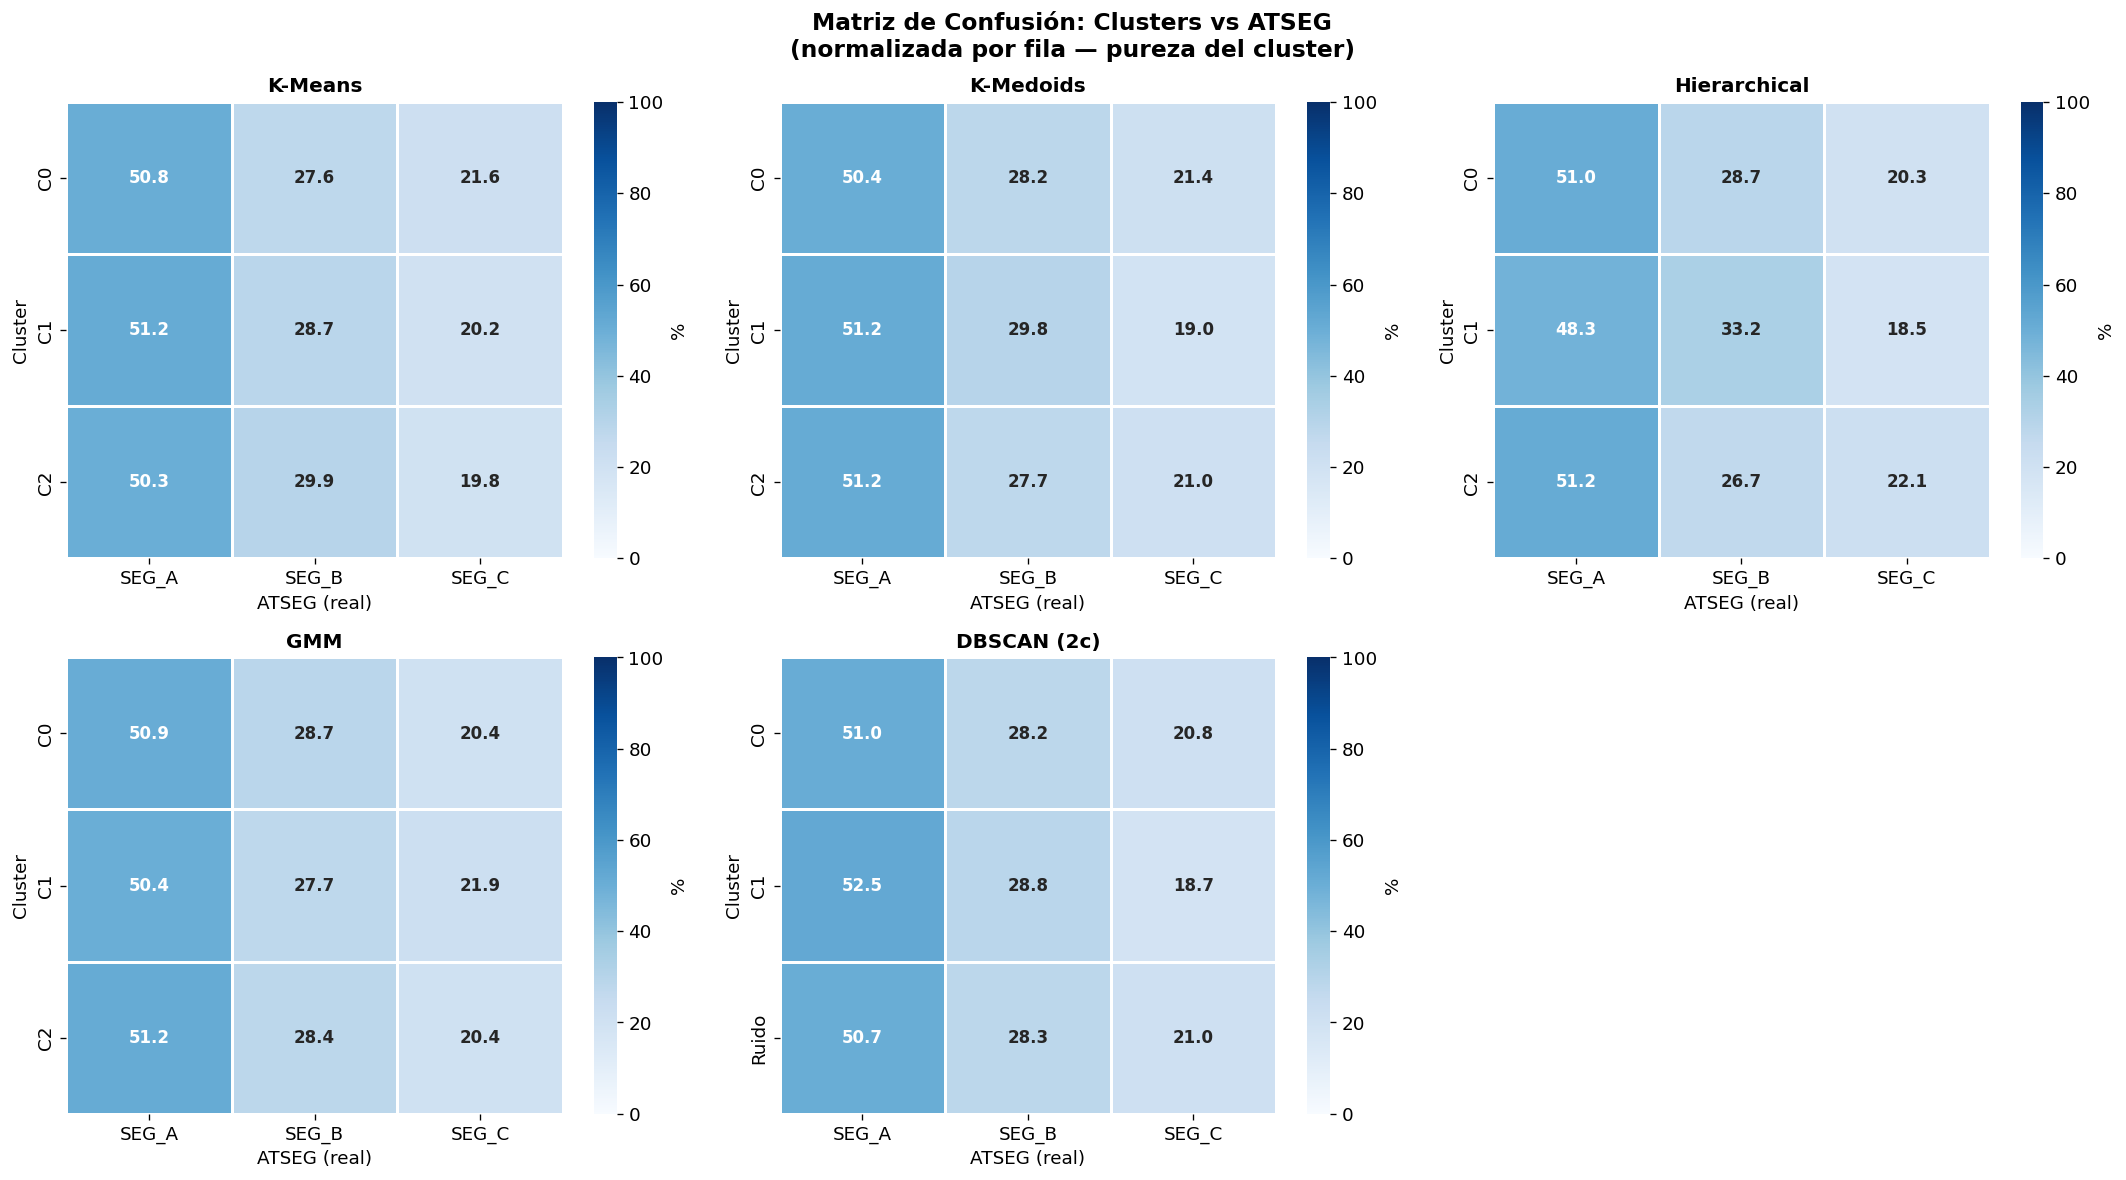

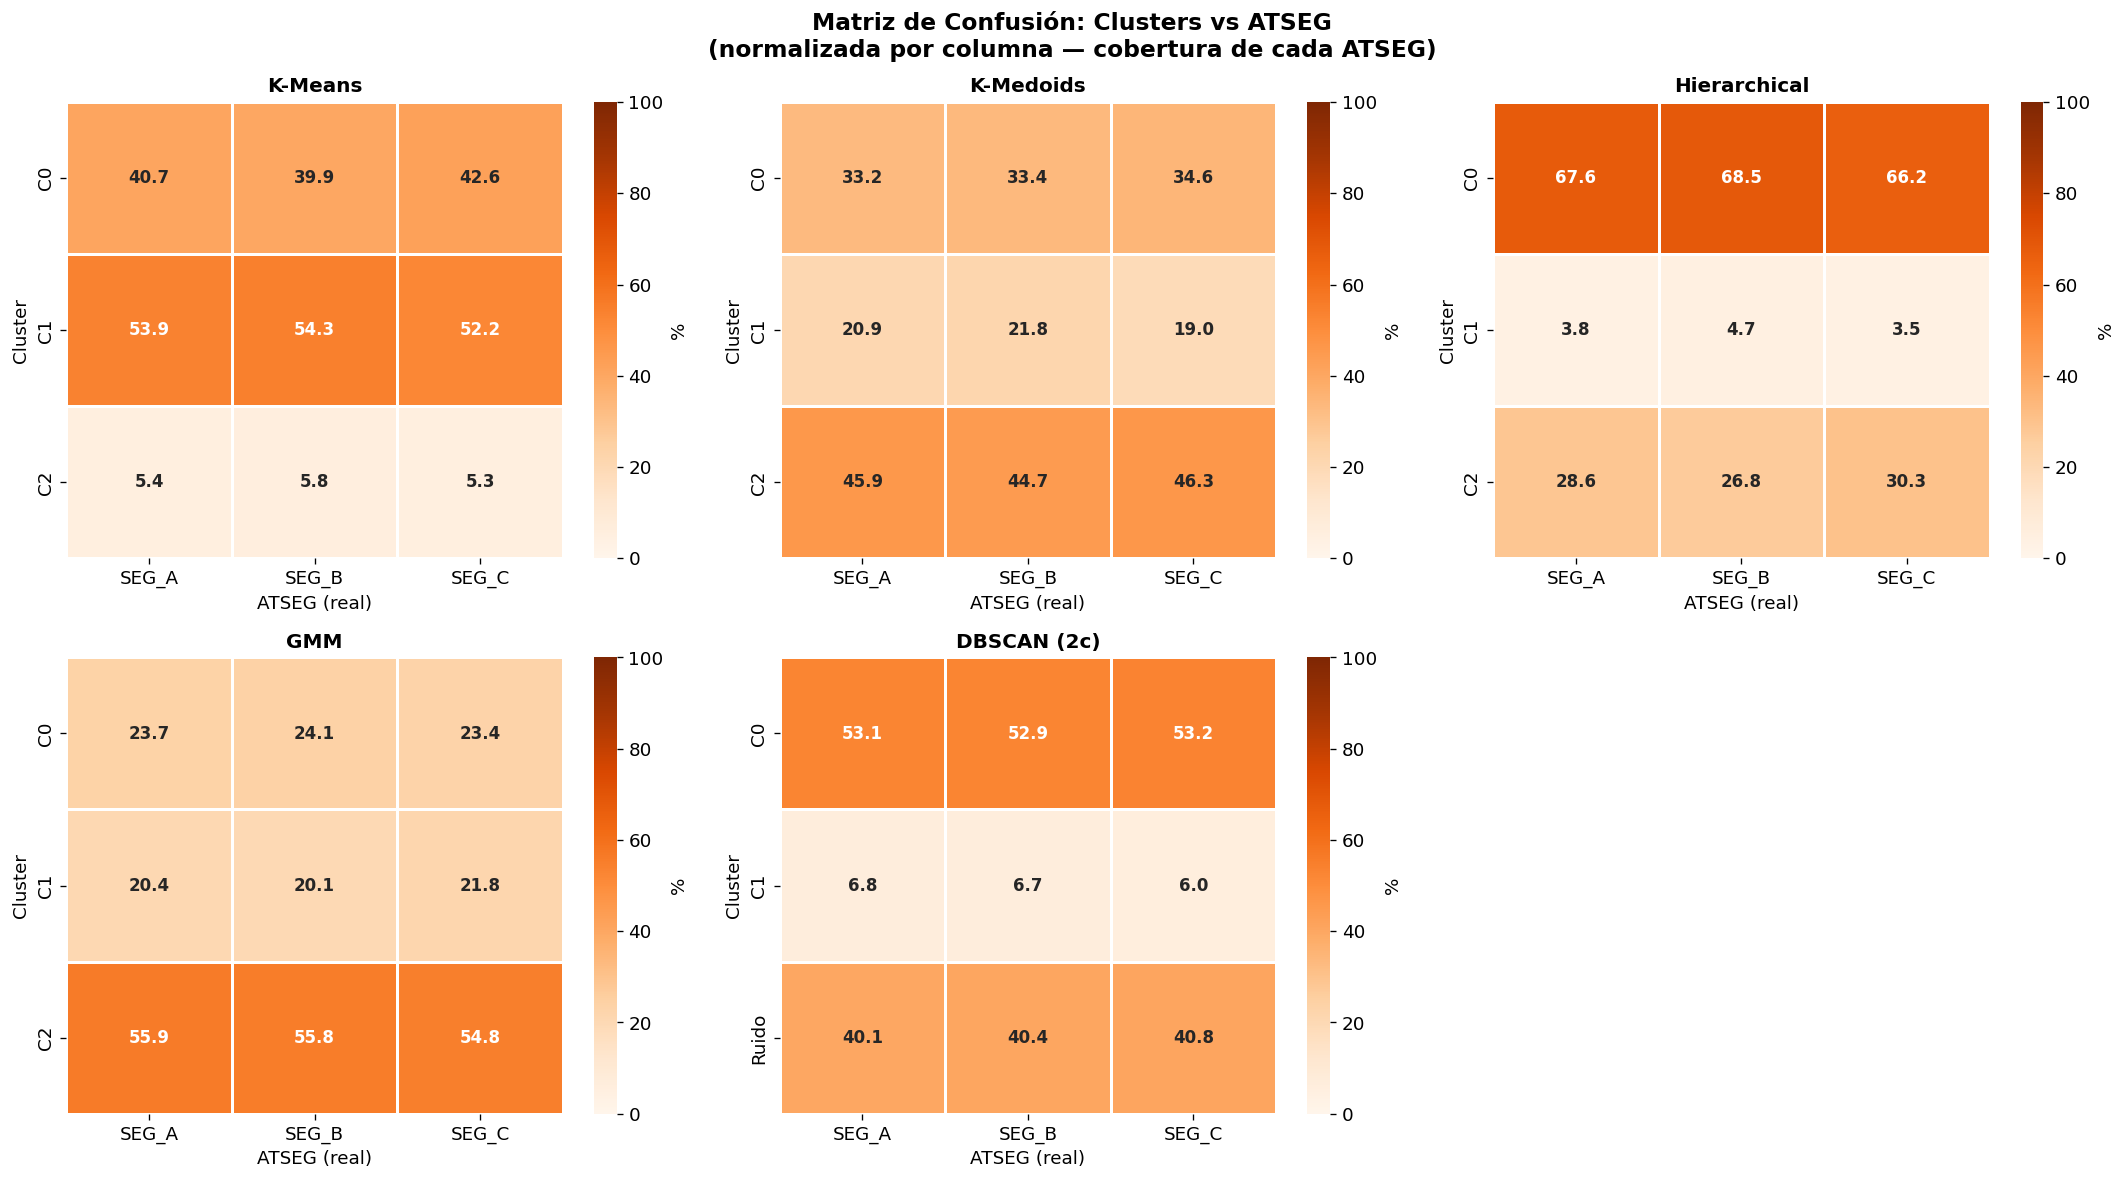

Azul (fila): pureza — qué % del cluster es de cada ATSEG
Naranja (columna): cobertura — qué % de cada ATSEG captura el cluster


In [137]:
# ── Matriz de confusión: Clusters vs ATSEG ──
has_atseg_cm = atseg.notna()
atseg_segs = ['SEG_A', 'SEG_B', 'SEG_C']

# Incluir todos los algoritmos k=3 + DBSCAN
algos_cm = dict(labels_k3)
if 'labels_dbscan' in dir():
    algos_cm[f'DBSCAN ({n_clusters_db}c)'] = labels_dbscan

n_cm = len(algos_cm)
ncols_cm = min(n_cm, 3)
nrows_cm = (n_cm + ncols_cm - 1) // ncols_cm

# ── 1) Normalizada por FILA: pureza del cluster ──
fig, axes = plt.subplots(nrows_cm, ncols_cm, figsize=(6 * ncols_cm, 5 * nrows_cm))
fig.suptitle('Matriz de Confusión: Clusters vs ATSEG\n'
             '(normalizada por fila — pureza del cluster)',
             fontsize=14, fontweight='bold')

ax_list = np.array(axes).flatten() if n_cm > 1 else [axes]

for idx, (algo_name, labels) in enumerate(algos_cm.items()):
    ax = ax_list[idx]
    mask_cm = has_atseg_cm
    if 'DBSCAN' in algo_name:
        labs_str = pd.Series([f'Ruido' if l == -1 else f'C{l}' for l in labels[mask_cm]])
    else:
        labs_str = pd.Series([f'C{l}' for l in labels[mask_cm]])

    ct = pd.crosstab(labs_str, atseg[mask_cm], normalize='index') * 100
    ct = ct[[c for c in atseg_segs if c in ct.columns]]
    ct = ct.sort_index()

    sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                vmin=0, vmax=100, cbar_kws={'label': '%'},
                linewidths=0.8, linecolor='white',
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_title(algo_name, fontweight='bold', fontsize=12)
    ax.set_xlabel('ATSEG (real)'); ax.set_ylabel('Cluster')

for idx in range(n_cm, len(ax_list)):
    ax_list[idx].set_visible(False)
plt.tight_layout()
plt.savefig('confusion_matrix_row_norm.png', bbox_inches='tight', dpi=130)
plt.show()

# ── 2) Normalizada por COLUMNA: cobertura ──
fig, axes = plt.subplots(nrows_cm, ncols_cm, figsize=(6 * ncols_cm, 5 * nrows_cm))
fig.suptitle('Matriz de Confusión: Clusters vs ATSEG\n'
             '(normalizada por columna — cobertura de cada ATSEG)',
             fontsize=14, fontweight='bold')

ax_list = np.array(axes).flatten() if n_cm > 1 else [axes]

for idx, (algo_name, labels) in enumerate(algos_cm.items()):
    ax = ax_list[idx]
    mask_cm = has_atseg_cm
    if 'DBSCAN' in algo_name:
        labs_str = pd.Series([f'Ruido' if l == -1 else f'C{l}' for l in labels[mask_cm]])
    else:
        labs_str = pd.Series([f'C{l}' for l in labels[mask_cm]])

    ct = pd.crosstab(labs_str, atseg[mask_cm], normalize='columns') * 100
    ct = ct[[c for c in atseg_segs if c in ct.columns]]
    ct = ct.sort_index()

    sns.heatmap(ct, annot=True, fmt='.1f', cmap='Oranges', ax=ax,
                vmin=0, vmax=100, cbar_kws={'label': '%'},
                linewidths=0.8, linecolor='white',
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_title(algo_name, fontweight='bold', fontsize=12)
    ax.set_xlabel('ATSEG (real)'); ax.set_ylabel('Cluster')

for idx in range(n_cm, len(ax_list)):
    ax_list[idx].set_visible(False)
plt.tight_layout()
plt.savefig('confusion_matrix_col_norm.png', bbox_inches='tight', dpi=130)
plt.show()

print('Azul (fila): pureza — qué % del cluster es de cada ATSEG')
print('Naranja (columna): cobertura — qué % de cada ATSEG captura el cluster')


## 12. Comparación cualitativa

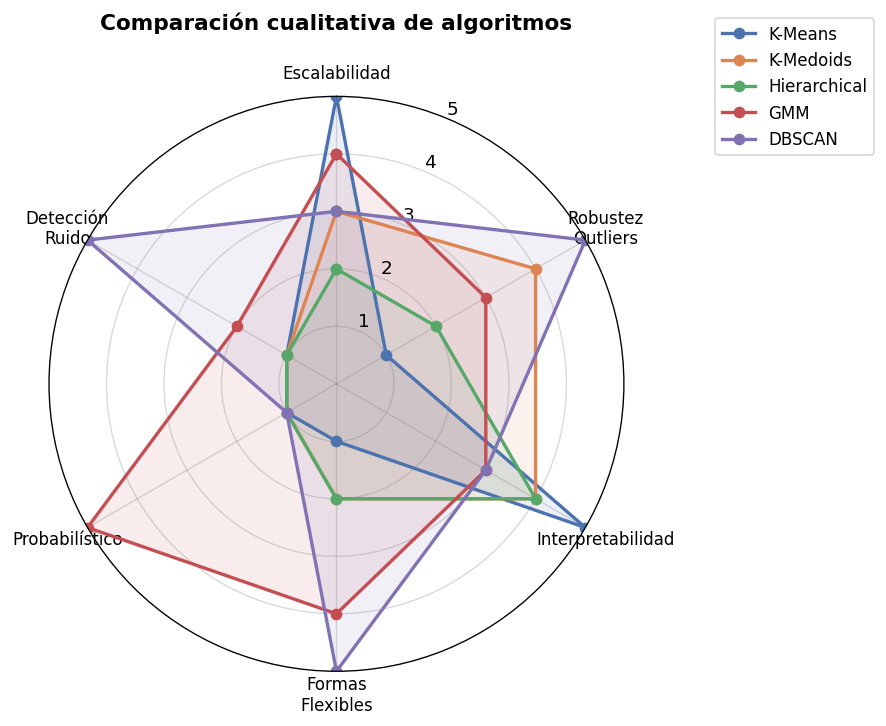

In [138]:
categories = ['Escalabilidad', 'Robustez\nOutliers', 'Interpretabilidad',
              'Formas\nFlexibles', 'Probabilístico', 'Detección\nRuido']
N_cat = len(categories)
scores_radar = {
    'K-Means':      [5, 1, 5, 1, 1, 1],
    'K-Medoids':    [3, 4, 4, 2, 1, 1],
    'Hierarchical': [2, 2, 4, 2, 1, 1],
    'GMM':          [4, 3, 3, 4, 5, 2],
    'DBSCAN':       [3, 5, 3, 5, 1, 5],
}
angles = np.linspace(0, 2*np.pi, N_cat, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 5); ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(color='gray', alpha=0.3)

for i, (algo, vals) in enumerate(scores_radar.items()):
    vp = vals + vals[:1]
    ax.plot(angles, vp, 'o-', lw=2, color=PALETTE[i], label=algo)
    ax.fill(angles, vp, alpha=0.1, color=PALETTE[i])

ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=10)
ax.set_title('Comparación cualitativa de algoritmos', y=1.1, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_doctors.png', bbox_inches='tight', dpi=130)
plt.show()

## 13. Conclusiones

### Estructura del análisis

Para cada algoritmo se siguió el mismo proceso:
1. **Búsqueda de k óptimo** (k=3..8) usando Silhouette Score (+ Inercia para K-Means, BIC/AIC para GMM)
2. **Ejecución con k_óptimo y k=3** sobre los mismos datos
3. **Comparación directa** de métricas: Silhouette, Davies-Bouldin, Calinski-Harabasz
4. **DBSCAN** no usa k — se selecciona eps automáticamente via k-distance plot y barrido

### Hallazgos clave

- **Restricción de negocio k=3:** Se compara directamente con el k óptimo estadístico.
- **Trade-off:** k=3 es comparable a ATSEG actual (3 segmentos); un k mayor aporta granularidad pero complica la operación.
- **Validación con ATSEG:** Los clusters se cruzaron con SEG_A/B/C para evaluar granularidad adicional.
- **DBSCAN:** Útil para detectar outliers y descubrir clusters de forma natural (sin fijar k). Los puntos etiquetados como ruido pueden representar doctores atípicos que merecen atención especial.

> **Recomendación:** Usar K-Means como algoritmo base para producción. K-Medoids para identificar doctores representativos (KOLs). GMM para scoring probabilístico suave. DBSCAN como complemento para detección de outliers y validación de la estructura natural de los datos.